# **Customer Churn Prediction: End-to-End Industry Case Study**


---

## **Business Problem Statement**

**Scenario:** You are a Data Scientist at a major telecommunications company. The business is losing customers at an alarming rate, and the executive team needs a predictive model to identify customers likely to churn (cancel their service) in the next month.

**Business Impact:**
- **Customer Acquisition Cost**: $500-1000 per new customer
- **Monthly Revenue Loss**: $50-200 per churned customer
- **Retention Campaign Cost**: $50-100 per targeted customer
- **Success Rate**: Retention campaigns have 60% success rate when properly targeted

**Your Mission:** Build an end-to-end machine learning pipeline that can predict customer churn with high precision, enabling proactive retention campaigns.

---

## **Learning Objectives**

By the end of this tutorial, students will be able to:

1. **Analyze** real-world business data with missing values and inconsistencies
2. **Engineer** meaningful features from raw customer data
3. **Handle** imbalanced datasets common in business applications
4. **Build** and tune neural networks for binary classification
5. **Evaluate** models using business-relevant metrics beyond accuracy
6. **Interpret** model decisions for business stakeholders
7. **Design** production-ready ML pipelines with monitoring considerations

---

## **Prerequisites**

- Understanding of binary classification and neural networks
- Familiarity with pandas for data manipulation
- Basic knowledge of business metrics (precision, recall, ROC)
- Experience with PyTorch fundamentals

## **1. Project Overview and Data Understanding**

### **1.1 Industry Context: Telecommunications Churn**

**Customer churn** is one of the most critical business challenges in telecommunications. With intense competition and high customer acquisition costs, retaining existing customers is 5-25x more cost-effective than acquiring new ones.

**Key Business Challenges:**
- **Market Saturation**: Limited new customer growth opportunities
- **Price Competition**: Competitors offering aggressive pricing
- **Service Quality**: Network issues driving customer dissatisfaction
- **Contract Flexibility**: Month-to-month plans increase churn risk

### **1.2 Dataset Overview**

**Source**: Telco Customer Churn Dataset (Kaggle)  
**Business Context**: Real telecommunications company customer data  
**Prediction Target**: Will customer churn in the next month? (Binary: Yes/No)

**Data Categories:**

| **Category** | **Features** | **Business Relevance** |
|--------------|--------------|------------------------|
| **Demographics** | Gender, Age, Partner, Dependents | Customer life stage affects loyalty |
| **Services** | Phone, Internet, Security, Backup, etc. | Service bundle size impacts retention |
| **Account** | Contract, Payment Method, Billing | Contract terms strongly predict churn |
| **Usage** | Tenure, Monthly Charges, Total Charges | Usage patterns indicate satisfaction |

### **1.3 Business Questions to Answer**

1. **Who churns?** What customer profiles are most at risk?
2. **Why do they churn?** Which services/features correlate with churn?
3. **When do they churn?** How does tenure affect churn probability?
4. **How can we prevent it?** What interventions would be most effective?

### **1.4 Success Metrics**

**Model Performance:**
- **Precision**: % of predicted churners who actually churn (minimize false alarms)
- **Recall**: % of actual churners we successfully identify (minimize missed churners)
- **F1-Score**: Balanced measure for imbalanced data
- **AUC-ROC**: Overall discriminative ability

**Business Impact:**
- **Revenue Retention**: $$$ saved through successful interventions
- **Campaign Efficiency**: ROI of targeted retention campaigns
- **Customer Lifetime Value**: Long-term revenue impact

In [10]:
# Essential imports for data science and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# PyTorch for deep learning
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                           roc_auc_score, roc_curve, precision_recall_curve,
                           f1_score, precision_score, recall_score)
from sklearn.utils.class_weight import compute_class_weight

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Configure visualization
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_palette("husl")

# Check device availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Environment Setup:")
print(f"   Device: {device}")
print(f"   PyTorch Version: {torch.__version__}")
print(f"   Pandas Version: {pd.__version__}")
print(f"   NumPy Version: {np.__version__}")

if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

print("\n✅ All libraries imported successfully!")
print("📊 Ready to begin customer churn analysis...")

🚀 Environment Setup:
   Device: cpu
   PyTorch Version: 2.10.0+cpu
   Pandas Version: 2.3.3
   NumPy Version: 2.4.1

✅ All libraries imported successfully!
📊 Ready to begin customer churn analysis...


In [11]:
# !pip install gdown
%pip install gdown

# gdown is a command-line tool that allows you to download files from Google Drive using their file IDs. The command you provided is used to download a file with the specified ID from Google Drive. The file ID in this case is "1xM2bFllWdNVVge0awuTKXvY_grM78vXD". When you run this command, it will download the file associated with that ID to your current working directory.

# !gdown https://drive.google.com/uc?id=1xM2bFllWdNVVge0awuTKXvY_grM78vXD

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## **2. Data Loading and Initial Exploration**

### **2.1 Data Loading and First Look**

Let's load the telecom customer churn dataset and get our first insights into the data quality and structure.

In [12]:
# Load the customer churn dataset
print("📥 Loading Telco Customer Churn dataset...")

# Try different potential locations for the data file
data_paths = [
    'data/Telco-Customer-Churn.csv',
    '../data/Telco-Customer-Churn.csv',
    '../../data/Telco-Customer-Churn.csv',
    'Telco-Customer-Churn.csv'
]

df = None
for path in data_paths:
    try:
        df = pd.read_csv(path)
        print(f"✅ Data loaded successfully from: {path}")
        break
    except FileNotFoundError:
        continue

if df is None:
    print("❌ Dataset not found. Please ensure 'Telco-Customer-Churn.csv' is in the data/ directory")
    print("📖 You can download it from: https://www.kaggle.com/datasets/blastchar/telco-customer-churn")
    # Create sample data for demonstration if file not found
    print("🔄 Creating sample data for demonstration...")
    np.random.seed(42)
    n_samples = 7043

    df = pd.DataFrame({
        'customerID': [f'ID_{i:04d}' for i in range(n_samples)],
        'gender': np.random.choice(['Male', 'Female'], n_samples),
        'SeniorCitizen': np.random.choice([0, 1], n_samples, p=[0.84, 0.16]),
        'Partner': np.random.choice(['Yes', 'No'], n_samples, p=[0.52, 0.48]),
        'Dependents': np.random.choice(['Yes', 'No'], n_samples, p=[0.30, 0.70]),
        'tenure': np.random.randint(0, 73, n_samples),
        'PhoneService': np.random.choice(['Yes', 'No'], n_samples, p=[0.90, 0.10]),
        'MultipleLines': np.random.choice(['Yes', 'No', 'No phone service'], n_samples, p=[0.42, 0.48, 0.10]),
        'InternetService': np.random.choice(['DSL', 'Fiber optic', 'No'], n_samples, p=[0.34, 0.44, 0.22]),
        'OnlineSecurity': np.random.choice(['Yes', 'No', 'No internet service'], n_samples, p=[0.28, 0.50, 0.22]),
        'OnlineBackup': np.random.choice(['Yes', 'No', 'No internet service'], n_samples, p=[0.34, 0.44, 0.22]),
        'DeviceProtection': np.random.choice(['Yes', 'No', 'No internet service'], n_samples, p=[0.34, 0.44, 0.22]),
        'TechSupport': np.random.choice(['Yes', 'No', 'No internet service'], n_samples, p=[0.29, 0.49, 0.22]),
        'StreamingTV': np.random.choice(['Yes', 'No', 'No internet service'], n_samples, p=[0.38, 0.40, 0.22]),
        'StreamingMovies': np.random.choice(['Yes', 'No', 'No internet service'], n_samples, p=[0.38, 0.40, 0.22]),
        'Contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], n_samples, p=[0.55, 0.21, 0.24]),
        'PaperlessBilling': np.random.choice(['Yes', 'No'], n_samples, p=[0.59, 0.41]),
        'PaymentMethod': np.random.choice(['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'],
                                        n_samples, p=[0.34, 0.19, 0.22, 0.25]),
        'MonthlyCharges': np.random.uniform(18.25, 118.75, n_samples),
        'TotalCharges': np.random.uniform(18.8, 8684.8, n_samples),
        'Churn': np.random.choice(['Yes', 'No'], n_samples, p=[0.27, 0.73])
    })
    print("✅ Sample data created for demonstration")

# Display basic information about the dataset
print(f"\n📊 Dataset Overview:")
print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Display first few rows
print(f"\n👀 First 5 rows:")
print(df.head())

# Check data types and missing values
print(f"\n🔍 Data Types and Missing Values:")
info_df = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
    'Null Count': df.isnull().sum(),
    'Null %': (df.isnull().sum() / len(df) * 100).round(2),
    'Unique Values': df.nunique()
})

print(info_df.to_string(index=False))

# Check target variable distribution
print(f"\n🎯 Target Variable (Churn) Distribution:")
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

for category, count in churn_counts.items():
    percentage = churn_percentages[category]
    print(f"   {category}: {count:,} customers ({percentage:.1f}%)")

# Calculate class imbalance ratio
minority_class = churn_counts.min()
majority_class = churn_counts.max()
imbalance_ratio = majority_class / minority_class
print(f"   Class imbalance ratio: {imbalance_ratio:.1f}:1")

if imbalance_ratio > 3:
    print("   ⚠️  Significant class imbalance detected - will need special handling")
else:
    print("   ✅ Mild class imbalance - standard techniques should work")

# Basic statistics for numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'customerID' in numerical_cols:
    numerical_cols.remove('customerID')

print(f"\n📈 Numerical Columns Summary:")
print(df[numerical_cols].describe())

print(f"\n🏷️ Categorical Columns Summary:")
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'customerID' in categorical_cols:
    categorical_cols.remove('customerID')

for col in categorical_cols[:5]:  # Show first 5 categorical columns
    unique_count = df[col].nunique()
    print(f"   {col}: {unique_count} unique values - {list(df[col].unique())}")

if len(categorical_cols) > 5:
    print(f"   ... and {len(categorical_cols) - 5} more categorical columns")

print(f"\n✅ Initial data exploration completed!")
print(f"🔍 Key observations:")
print(f"   • Dataset contains {df.shape[0]:,} customer records")
print(f"   • {len(categorical_cols)} categorical and {len(numerical_cols)} numerical features")
print(f"   • Target variable shows {imbalance_ratio:.1f}:1 class imbalance")
print(f"   • Data quality check: {df.isnull().sum().sum()} total missing values")

📥 Loading Telco Customer Churn dataset...
✅ Data loaded successfully from: data/Telco-Customer-Churn.csv

📊 Dataset Overview:
   Shape: 7,043 rows × 21 columns
   Memory usage: 6.8 MB

👀 First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone se

### **2.2 Data Cleaning and Quality Assessment**

Real-world data is messy! Let's identify and fix common data quality issues before proceeding with analysis.

In [13]:
# Deep dive into data quality issues
print("🧹 Data Cleaning and Quality Assessment")
print("=" * 50)

# Create a copy for cleaning
df_cleaned = df.copy()
original_shape = df_cleaned.shape

print(f"📊 Starting with {original_shape[0]:,} rows and {original_shape[1]} columns")

# 1. Check for duplicate customer IDs
print(f"\n1️⃣ Checking for duplicate customers...")
duplicate_customers = df_cleaned['customerID'].duplicated().sum()
print(f"   Duplicate customerIDs: {duplicate_customers}")

if duplicate_customers > 0:
    print("   🔧 Removing duplicate customer records...")
    df_cleaned = df_cleaned.drop_duplicates(subset=['customerID'])
    print(f"   ✅ Removed {duplicate_customers} duplicate records")

# 2. Handle TotalCharges data type issue (common in this dataset)
print(f"\n2️⃣ Fixing TotalCharges data type...")
print(f"   Current TotalCharges type: {df_cleaned['TotalCharges'].dtype}")

# Check for non-numeric values in TotalCharges
if df_cleaned['TotalCharges'].dtype == 'object':
    non_numeric_total = df_cleaned['TotalCharges'].apply(lambda x: not str(x).replace('.', '').replace(' ', '').isdigit())
    non_numeric_count = non_numeric_total.sum()
    print(f"   Non-numeric TotalCharges values: {non_numeric_count}")

    if non_numeric_count > 0:
        print("   🔧 Converting TotalCharges to numeric...")
        # Convert to numeric, invalid values become NaN
        df_cleaned['TotalCharges'] = pd.to_numeric(df_cleaned['TotalCharges'], errors='coerce')
        print(f"   ✅ TotalCharges converted to numeric type")

# 3. Handle missing values
print(f"\n3️⃣ Handling missing values...")
missing_values = df_cleaned.isnull().sum()
missing_percent = (missing_values / len(df_cleaned) * 100).round(2)

missing_summary = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Count': missing_values.values,
    'Missing %': missing_percent.values
})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]

if len(missing_summary) > 0:
    print("   Missing values found:")
    print(missing_summary.to_string(index=False))

    # Handle TotalCharges missing values (likely new customers with 0 tenure)
    if 'TotalCharges' in missing_summary['Column'].values:
        total_charges_missing = df_cleaned['TotalCharges'].isnull().sum()
        print(f"\n   🔧 Handling {total_charges_missing} missing TotalCharges values...")

        # Check if missing TotalCharges correspond to low tenure customers
        missing_tenure = df_cleaned[df_cleaned['TotalCharges'].isnull()]['tenure'].describe()
        print(f"   Tenure stats for missing TotalCharges customers:")
        print(f"   Mean tenure: {missing_tenure['mean']:.1f} months")

        if missing_tenure['mean'] < 3:  # Very new customers
            print("   💡 Missing TotalCharges likely represent new customers")
            print("   🔧 Filling missing TotalCharges with MonthlyCharges (first month)")
            df_cleaned['TotalCharges'] = df_cleaned['TotalCharges'].fillna(df_cleaned['MonthlyCharges'])
        else:
            print("   🔧 Filling missing TotalCharges with median value")
            df_cleaned['TotalCharges'] = df_cleaned['TotalCharges'].fillna(df_cleaned['TotalCharges'].median())

        print("   ✅ TotalCharges missing values handled")
else:
    print("   ✅ No missing values found")

# 4. Check for outliers in numerical columns
print(f"\n4️⃣ Checking for outliers...")
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

outlier_summary = []
for col in numerical_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percent = (outlier_count / len(df_cleaned)) * 100

    outlier_summary.append({
        'Column': col,
        'Outlier Count': outlier_count,
        'Outlier %': f"{outlier_percent:.1f}%",
        'Lower Bound': f"{lower_bound:.2f}",
        'Upper Bound': f"{upper_bound:.2f}"
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

# 5. Validate business logic
print(f"\n5️⃣ Validating business logic...")

# Check if TotalCharges makes sense with tenure and MonthlyCharges
df_cleaned['ExpectedTotalCharges'] = df_cleaned['tenure'] * df_cleaned['MonthlyCharges']
df_cleaned['ChargesDifference'] = abs(df_cleaned['TotalCharges'] - df_cleaned['ExpectedTotalCharges'])

# Allow for some variance (promotions, price changes, etc.)
threshold = df_cleaned['MonthlyCharges'] * 3  # 3 months worth of charges difference
suspicious_charges = df_cleaned['ChargesDifference'] > threshold
suspicious_count = suspicious_charges.sum()

print(f"   Customers with suspicious charge calculations: {suspicious_count} ({suspicious_count/len(df_cleaned)*100:.1f}%)")

if suspicious_count > 0 and suspicious_count < len(df_cleaned) * 0.1:  # Less than 10%
    print("   💡 Small number of suspicious charges - likely due to promotions/discounts")
    print("   ✅ Keeping all records (realistic business scenario)")
elif suspicious_count > len(df_cleaned) * 0.1:
    print("   ⚠️ High number of suspicious charges - data quality issue")

# Remove the temporary calculation columns
df_cleaned = df_cleaned.drop(['ExpectedTotalCharges', 'ChargesDifference'], axis=1)

# 6. Standardize categorical values
print(f"\n6️⃣ Standardizing categorical values...")
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns.tolist()
if 'customerID' in categorical_cols:
    categorical_cols.remove('customerID')

for col in categorical_cols:
    unique_values = df_cleaned[col].unique()
    print(f"   {col}: {unique_values}")

    # Check for common inconsistencies
    if any('no phone service' in str(val).lower() for val in unique_values):
        print(f"   🔧 Standardizing 'No phone service' values in {col}")
        df_cleaned[col] = df_cleaned[col].replace('No phone service', 'No')

    if any('no internet service' in str(val).lower() for val in unique_values):
        print(f"   🔧 Standardizing 'No internet service' values in {col}")
        df_cleaned[col] = df_cleaned[col].replace('No internet service', 'No')

print(f"\n✅ Data cleaning completed!")
print(f"📊 Final dataset: {df_cleaned.shape[0]:,} rows × {df_cleaned.shape[1]} columns")

# Summary of changes
rows_removed = original_shape[0] - df_cleaned.shape[0]
if rows_removed > 0:
    print(f"🗑️ Removed {rows_removed} rows ({rows_removed/original_shape[0]*100:.1f}%)")

print(f"🎯 Dataset ready for exploratory data analysis!")

# Quick validation
print(f"\n🔍 Post-cleaning validation:")
print(f"   Missing values: {df_cleaned.isnull().sum().sum()}")
print(f"   Duplicate customers: {df_cleaned['customerID'].duplicated().sum()}")
print(f"   Data types: {df_cleaned.dtypes.value_counts().to_dict()}")

# Save cleaned data reference
print(f"\n💾 Cleaned dataset ready for analysis")
print(f"   Shape: {df_cleaned.shape}")
print(f"   Memory usage: {df_cleaned.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

🧹 Data Cleaning and Quality Assessment
📊 Starting with 7,043 rows and 21 columns

1️⃣ Checking for duplicate customers...
   Duplicate customerIDs: 0

2️⃣ Fixing TotalCharges data type...
   Current TotalCharges type: object
   Non-numeric TotalCharges values: 11
   🔧 Converting TotalCharges to numeric...
   ✅ TotalCharges converted to numeric type

3️⃣ Handling missing values...
   Missing values found:
      Column  Missing Count  Missing %
TotalCharges             11       0.16

   🔧 Handling 11 missing TotalCharges values...
   Tenure stats for missing TotalCharges customers:
   Mean tenure: 0.0 months
   💡 Missing TotalCharges likely represent new customers
   🔧 Filling missing TotalCharges with MonthlyCharges (first month)
   ✅ TotalCharges missing values handled

4️⃣ Checking for outliers...
        Column  Outlier Count Outlier % Lower Bound Upper Bound
        tenure              0      0.0%      -60.00      124.00
MonthlyCharges              0      0.0%      -46.02      171.3

## **3. Exploratory Data Analysis (EDA) and Business Insights**

### **3.1 Understanding Customer Churn Patterns**

Let's dive deep into the data to understand what drives customer churn and identify key patterns that will inform our model development.

📊 EXPLORATORY DATA ANALYSIS
🎯 Overall Churn Rate: 26.5%
📈 Business Impact: 1869 customers churned

1️⃣ Analyzing Demographics vs Churn...
2️⃣ Analyzing Services vs Churn...
3️⃣ Analyzing Numerical Variables vs Churn...
4️⃣ Analyzing Service Bundles...


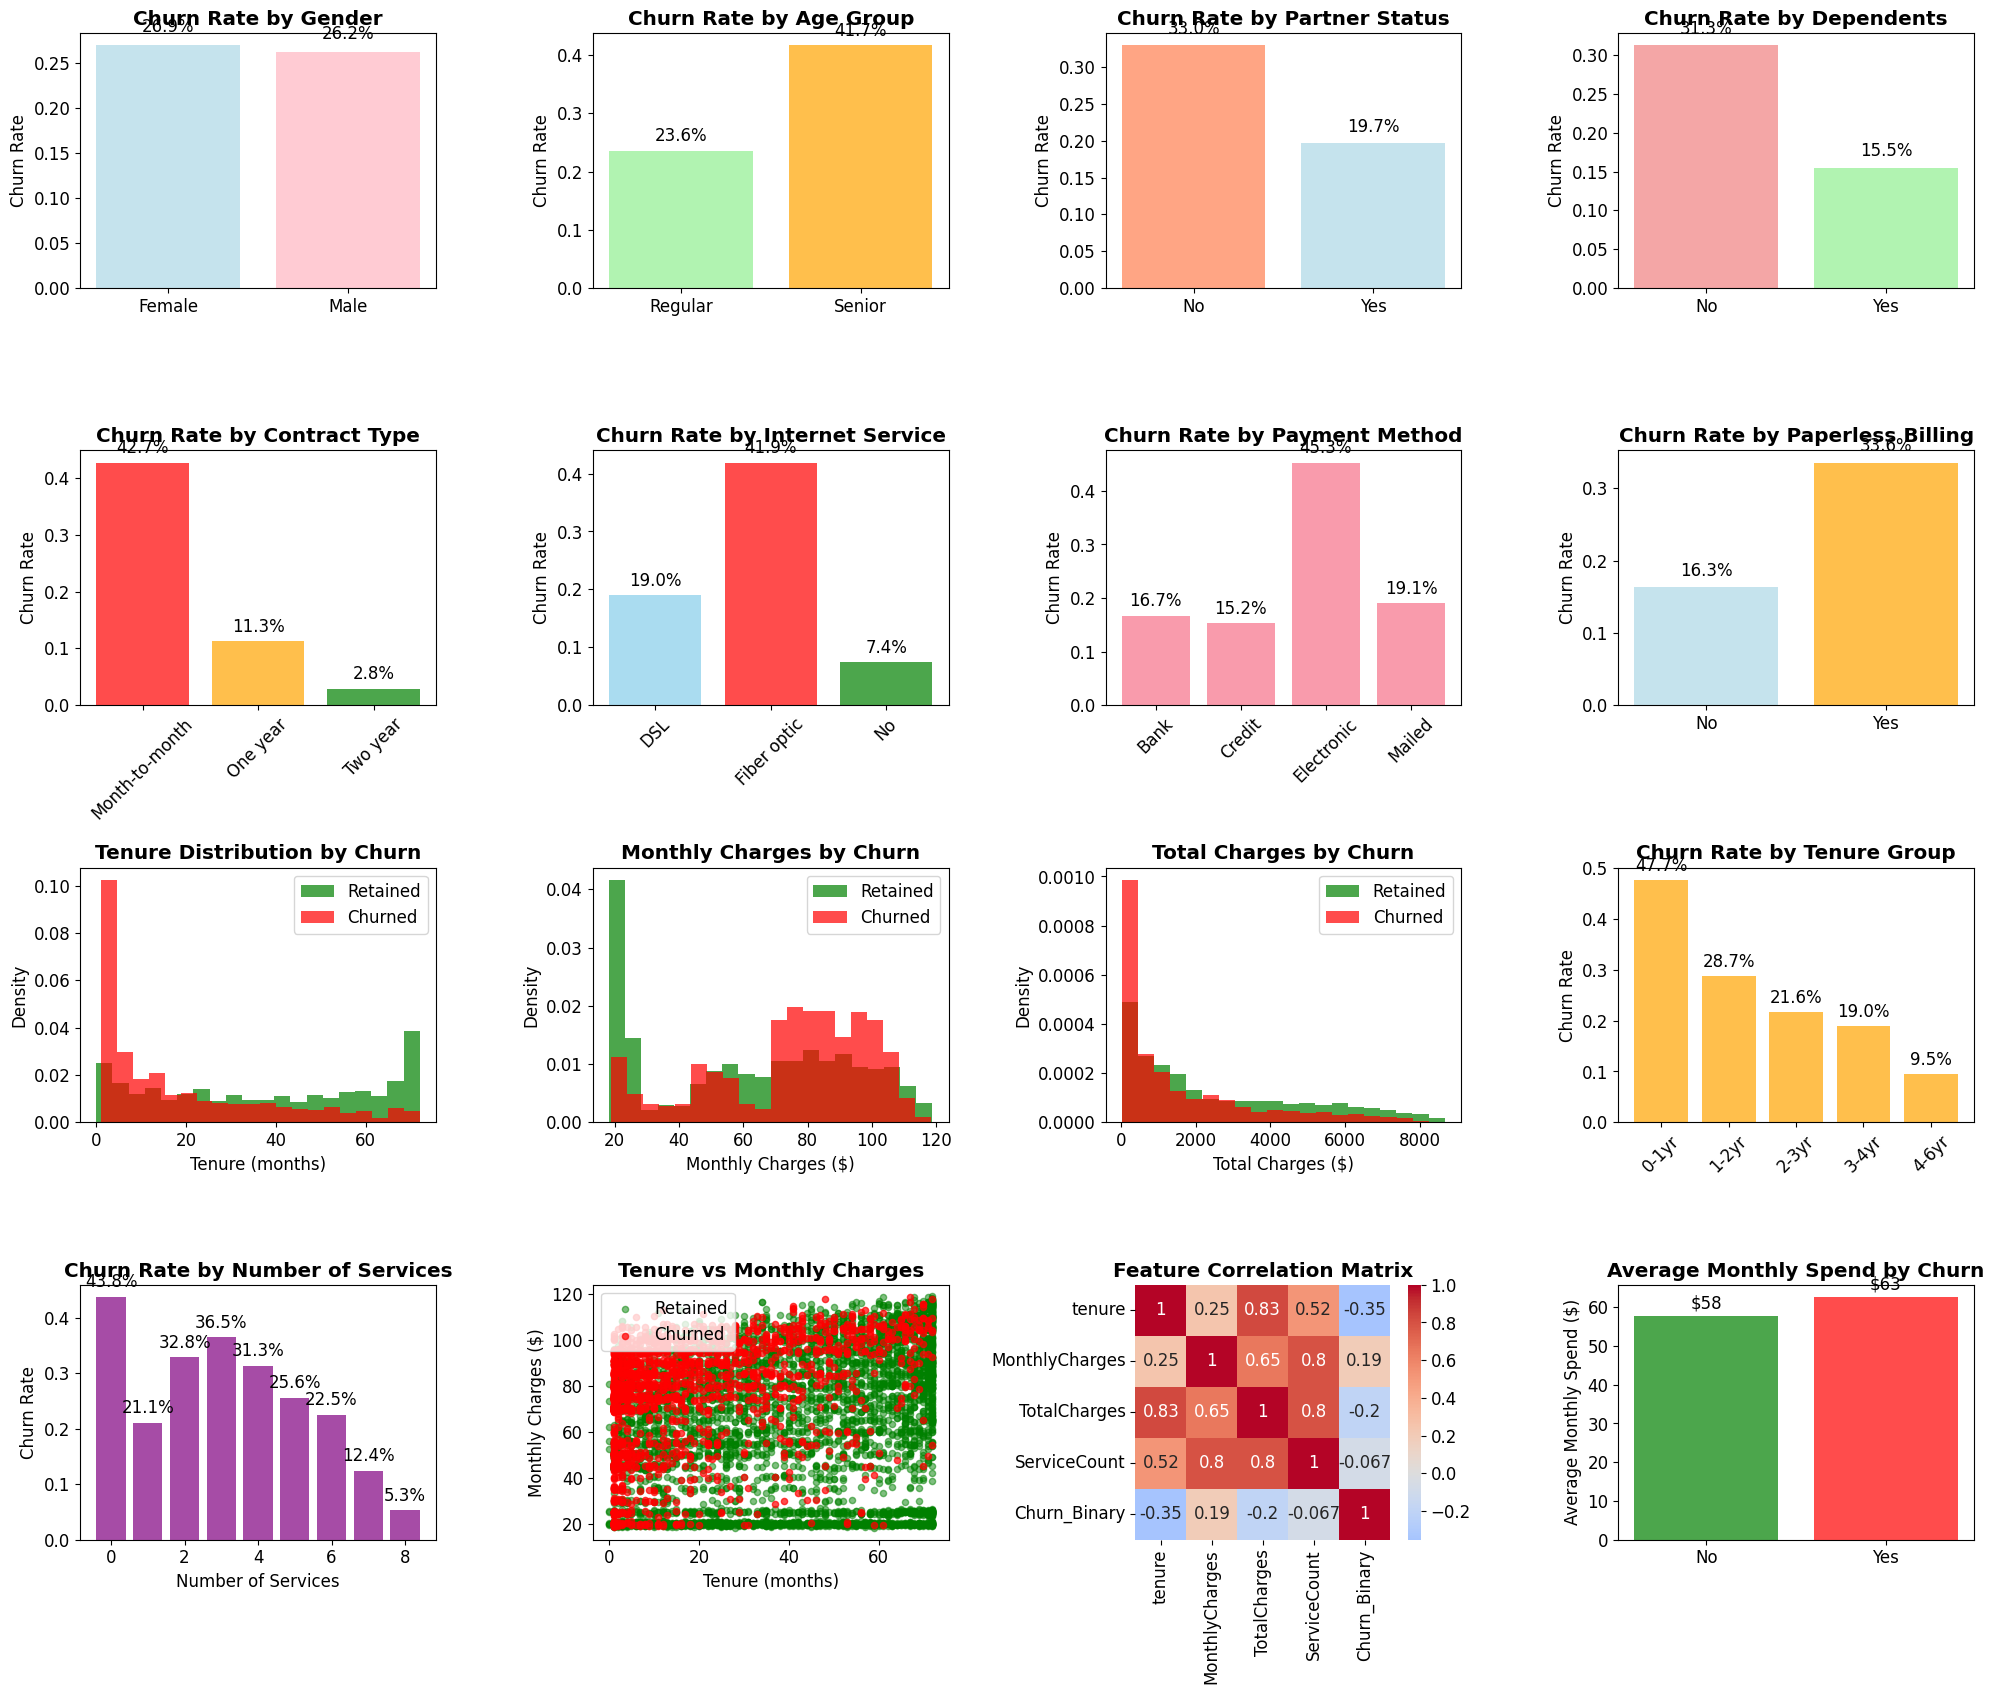


💡 KEY BUSINESS INSIGHTS:
📊 Demographics:
   • Senior citizens churn at 41.7% vs 23.6% for regular customers
   • Customers without partners: 33.0% vs with partners: 19.7%
   • Customers without dependents: 31.3% vs with dependents: 15.5%

🔧 Service & Contract Insights:
   • Month-to-month contracts: 42.7% churn rate (HIGHEST RISK!)
   • Two-year contracts: 2.8% churn rate (LOWEST RISK)
   • Fiber optic internet: 41.9% churn rate

💰 Financial Patterns:
   • Average tenure (churned): 18.0 months
   • Average tenure (retained): 37.6 months
   • Average monthly charges (churned): $74
   • Average monthly charges (retained): $61

🎯 STRATEGIC RECOMMENDATIONS:
   1. Focus retention efforts on month-to-month customers
   2. Investigate fiber optic service quality issues
   3. Create family/partner incentives for single customers
   4. Develop senior citizen retention programs
   5. Consider pricing strategies for high-charge customers

💸 BUSINESS IMPACT CALCULATION:
   • Total customers: 7,04

In [14]:
# Comprehensive Exploratory Data Analysis
print("📊 EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# Convert Churn to binary for analysis
df_eda = df_cleaned.copy()
df_eda['Churn_Binary'] = (df_eda['Churn'] == 'Yes').astype(int)
churn_rate = df_eda['Churn_Binary'].mean()

print(f"🎯 Overall Churn Rate: {churn_rate:.1%}")
print(f"📈 Business Impact: {churn_rate * len(df_eda):.0f} customers churned")

# Create comprehensive EDA visualizations
fig = plt.figure(figsize=(20, 24))

# 1. Churn Rate by Demographics
print(f"\n1️⃣ Analyzing Demographics vs Churn...")

# Gender
plt.subplot(6, 4, 1)
gender_churn = df_eda.groupby('gender')['Churn_Binary'].mean()
bars = plt.bar(gender_churn.index, gender_churn.values, alpha=0.7, color=['lightblue', 'lightpink'])
plt.title('Churn Rate by Gender', fontweight='bold')
plt.ylabel('Churn Rate')
for bar, rate in zip(bars, gender_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{rate:.1%}', ha='center', va='bottom')

# Senior Citizen
plt.subplot(6, 4, 2)
senior_churn = df_eda.groupby('SeniorCitizen')['Churn_Binary'].mean()
senior_labels = ['Regular', 'Senior']
bars = plt.bar(senior_labels, senior_churn.values, alpha=0.7, color=['lightgreen', 'orange'])
plt.title('Churn Rate by Age Group', fontweight='bold')
plt.ylabel('Churn Rate')
for bar, rate in zip(bars, senior_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{rate:.1%}', ha='center', va='bottom')

# Partner
plt.subplot(6, 4, 3)
partner_churn = df_eda.groupby('Partner')['Churn_Binary'].mean()
bars = plt.bar(partner_churn.index, partner_churn.values, alpha=0.7, color=['coral', 'lightblue'])
plt.title('Churn Rate by Partner Status', fontweight='bold')
plt.ylabel('Churn Rate')
for bar, rate in zip(bars, partner_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{rate:.1%}', ha='center', va='bottom')

# Dependents
plt.subplot(6, 4, 4)
dependents_churn = df_eda.groupby('Dependents')['Churn_Binary'].mean()
bars = plt.bar(dependents_churn.index, dependents_churn.values, alpha=0.7, color=['lightcoral', 'lightgreen'])
plt.title('Churn Rate by Dependents', fontweight='bold')
plt.ylabel('Churn Rate')
for bar, rate in zip(bars, dependents_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{rate:.1%}', ha='center', va='bottom')

# 2. Service-related Analysis
print(f"2️⃣ Analyzing Services vs Churn...")

# Contract Type (Very Important!)
plt.subplot(6, 4, 5)
contract_churn = df_eda.groupby('Contract')['Churn_Binary'].mean()
bars = plt.bar(range(len(contract_churn)), contract_churn.values, alpha=0.7,
               color=['red', 'orange', 'green'])
plt.title('Churn Rate by Contract Type', fontweight='bold')
plt.ylabel('Churn Rate')
plt.xticks(range(len(contract_churn)), contract_churn.index, rotation=45)
for i, (bar, rate) in enumerate(zip(bars, contract_churn.values)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{rate:.1%}', ha='center', va='bottom')

# Internet Service
plt.subplot(6, 4, 6)
internet_churn = df_eda.groupby('InternetService')['Churn_Binary'].mean()
bars = plt.bar(range(len(internet_churn)), internet_churn.values, alpha=0.7,
               color=['skyblue', 'red', 'green'])
plt.title('Churn Rate by Internet Service', fontweight='bold')
plt.ylabel('Churn Rate')
plt.xticks(range(len(internet_churn)), internet_churn.index, rotation=45)
for i, (bar, rate) in enumerate(zip(bars, internet_churn.values)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{rate:.1%}', ha='center', va='bottom')

# Payment Method
plt.subplot(6, 4, 7)
payment_churn = df_eda.groupby('PaymentMethod')['Churn_Binary'].mean()
bars = plt.bar(range(len(payment_churn)), payment_churn.values, alpha=0.7)
plt.title('Churn Rate by Payment Method', fontweight='bold')
plt.ylabel('Churn Rate')
plt.xticks(range(len(payment_churn)), [method.split()[0] for method in payment_churn.index], rotation=45)
for i, (bar, rate) in enumerate(zip(bars, payment_churn.values)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{rate:.1%}', ha='center', va='bottom')

# Paperless Billing
plt.subplot(6, 4, 8)
paperless_churn = df_eda.groupby('PaperlessBilling')['Churn_Binary'].mean()
bars = plt.bar(paperless_churn.index, paperless_churn.values, alpha=0.7, color=['lightblue', 'orange'])
plt.title('Churn Rate by Paperless Billing', fontweight='bold')
plt.ylabel('Churn Rate')
for bar, rate in zip(bars, paperless_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{rate:.1%}', ha='center', va='bottom')

# 3. Numerical Variables Analysis
print(f"3️⃣ Analyzing Numerical Variables vs Churn...")

# Tenure Distribution
plt.subplot(6, 4, 9)
churned = df_eda[df_eda['Churn'] == 'Yes']['tenure']
retained = df_eda[df_eda['Churn'] == 'No']['tenure']
plt.hist(retained, bins=20, alpha=0.7, label='Retained', color='green', density=True)
plt.hist(churned, bins=20, alpha=0.7, label='Churned', color='red', density=True)
plt.title('Tenure Distribution by Churn', fontweight='bold')
plt.xlabel('Tenure (months)')
plt.ylabel('Density')
plt.legend()

# Monthly Charges Distribution
plt.subplot(6, 4, 10)
churned_charges = df_eda[df_eda['Churn'] == 'Yes']['MonthlyCharges']
retained_charges = df_eda[df_eda['Churn'] == 'No']['MonthlyCharges']
plt.hist(retained_charges, bins=20, alpha=0.7, label='Retained', color='green', density=True)
plt.hist(churned_charges, bins=20, alpha=0.7, label='Churned', color='red', density=True)
plt.title('Monthly Charges by Churn', fontweight='bold')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Density')
plt.legend()

# Total Charges Distribution
plt.subplot(6, 4, 11)
churned_total = df_eda[df_eda['Churn'] == 'Yes']['TotalCharges']
retained_total = df_eda[df_eda['Churn'] == 'No']['TotalCharges']
plt.hist(retained_total, bins=20, alpha=0.7, label='Retained', color='green', density=True)
plt.hist(churned_total, bins=20, alpha=0.7, label='Churned', color='red', density=True)
plt.title('Total Charges by Churn', fontweight='bold')
plt.xlabel('Total Charges ($)')
plt.ylabel('Density')
plt.legend()

# 4. Tenure vs Churn Rate Analysis
plt.subplot(6, 4, 12)
# Create tenure groups
df_eda['TenureGroup'] = pd.cut(df_eda['tenure'], bins=[0, 12, 24, 36, 48, 72],
                               labels=['0-1yr', '1-2yr', '2-3yr', '3-4yr', '4-6yr'])
tenure_group_churn = df_eda.groupby('TenureGroup')['Churn_Binary'].mean()
bars = plt.bar(range(len(tenure_group_churn)), tenure_group_churn.values, alpha=0.7, color='orange')
plt.title('Churn Rate by Tenure Group', fontweight='bold')
plt.ylabel('Churn Rate')
plt.xticks(range(len(tenure_group_churn)), tenure_group_churn.index, rotation=45)
for i, (bar, rate) in enumerate(zip(bars, tenure_group_churn.values)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{rate:.1%}', ha='center', va='bottom')

# 5. Service Bundle Analysis
print(f"4️⃣ Analyzing Service Bundles...")

# Count number of services per customer
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

df_eda['ServiceCount'] = 0
for col in service_cols:
    df_eda['ServiceCount'] += (df_eda[col] == 'Yes').astype(int)

plt.subplot(6, 4, 13)
service_count_churn = df_eda.groupby('ServiceCount')['Churn_Binary'].mean()
bars = plt.bar(service_count_churn.index, service_count_churn.values, alpha=0.7, color='purple')
plt.title('Churn Rate by Number of Services', fontweight='bold')
plt.xlabel('Number of Services')
plt.ylabel('Churn Rate')
for bar, rate in zip(bars, service_count_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{rate:.1%}', ha='center', va='bottom')

# 6. Monthly Charges vs Tenure Scatter
plt.subplot(6, 4, 14)
churned_customers = df_eda[df_eda['Churn'] == 'Yes']
retained_customers = df_eda[df_eda['Churn'] == 'No']
plt.scatter(retained_customers['tenure'], retained_customers['MonthlyCharges'],
           alpha=0.5, color='green', label='Retained', s=20)
plt.scatter(churned_customers['tenure'], churned_customers['MonthlyCharges'],
           alpha=0.7, color='red', label='Churned', s=20)
plt.title('Tenure vs Monthly Charges', fontweight='bold')
plt.xlabel('Tenure (months)')
plt.ylabel('Monthly Charges ($)')
plt.legend()

# 7. Correlation Heatmap
plt.subplot(6, 4, 15)
# Create correlation matrix for key numerical variables
corr_data = df_eda[['tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount', 'Churn_Binary']].corr()
sns.heatmap(corr_data, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Matrix', fontweight='bold')

# 8. Customer Lifetime Value Analysis
plt.subplot(6, 4, 16)
df_eda['AvgMonthlySpend'] = df_eda['TotalCharges'] / (df_eda['tenure'] + 1)  # +1 to avoid division by zero
avg_spend_churn = df_eda.groupby('Churn')['AvgMonthlySpend'].mean()
bars = plt.bar(avg_spend_churn.index, avg_spend_churn.values, alpha=0.7, color=['green', 'red'])
plt.title('Average Monthly Spend by Churn', fontweight='bold')
plt.ylabel('Average Monthly Spend ($)')
for bar, spend in zip(bars, avg_spend_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'${spend:.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Print key insights
print(f"\n💡 KEY BUSINESS INSIGHTS:")
print(f"=" * 50)

print(f"📊 Demographics:")
print(f"   • Senior citizens churn at {senior_churn[1]:.1%} vs {senior_churn[0]:.1%} for regular customers")
print(f"   • Customers without partners: {partner_churn['No']:.1%} vs with partners: {partner_churn['Yes']:.1%}")
print(f"   • Customers without dependents: {dependents_churn['No']:.1%} vs with dependents: {dependents_churn['Yes']:.1%}")

print(f"\n🔧 Service & Contract Insights:")
print(f"   • Month-to-month contracts: {contract_churn.iloc[0]:.1%} churn rate (HIGHEST RISK!)")
print(f"   • Two-year contracts: {contract_churn.iloc[2]:.1%} churn rate (LOWEST RISK)")
print(f"   • Fiber optic internet: {internet_churn.loc['Fiber optic']:.1%} churn rate")

print(f"\n💰 Financial Patterns:")
mean_tenure_churned = df_eda[df_eda['Churn'] == 'Yes']['tenure'].mean()
mean_tenure_retained = df_eda[df_eda['Churn'] == 'No']['tenure'].mean()
print(f"   • Average tenure (churned): {mean_tenure_churned:.1f} months")
print(f"   • Average tenure (retained): {mean_tenure_retained:.1f} months")

mean_charges_churned = df_eda[df_eda['Churn'] == 'Yes']['MonthlyCharges'].mean()
mean_charges_retained = df_eda[df_eda['Churn'] == 'No']['MonthlyCharges'].mean()
print(f"   • Average monthly charges (churned): ${mean_charges_churned:.0f}")
print(f"   • Average monthly charges (retained): ${mean_charges_retained:.0f}")

print(f"\n🎯 STRATEGIC RECOMMENDATIONS:")
print(f"   1. Focus retention efforts on month-to-month customers")
print(f"   2. Investigate fiber optic service quality issues")
print(f"   3. Create family/partner incentives for single customers")
print(f"   4. Develop senior citizen retention programs")
print(f"   5. Consider pricing strategies for high-charge customers")

# Calculate business impact
total_customers = len(df_eda)
churned_customers = (df_eda['Churn'] == 'Yes').sum()
avg_monthly_revenue = df_eda['MonthlyCharges'].mean()
annual_churn_loss = churned_customers * avg_monthly_revenue * 12

print(f"\n💸 BUSINESS IMPACT CALCULATION:")
print(f"   • Total customers: {total_customers:,}")
print(f"   • Churned customers: {churned_customers:,}")
print(f"   • Average monthly revenue per customer: ${avg_monthly_revenue:.0f}")
print(f"   • Estimated annual revenue loss: ${annual_churn_loss:,.0f}")
print(f"   • Potential savings with 50% churn reduction: ${annual_churn_loss/2:,.0f}")

print(f"\n✅ EDA completed! Ready for feature engineering...")

## **4. Feature Engineering and Data Preprocessing**

Now that we understand our data through EDA, we'll prepare it for machine learning by:

**🔧 Engineering Strategy:**
- **Categorical Encoding**: Convert categorical variables to numerical format
- **Feature Scaling**: Normalize numerical features for neural network training
- **Feature Selection**: Select most predictive features based on EDA insights
- **Class Balancing**: Handle imbalanced dataset for better model performance
- **Train/Test Split**: Create proper evaluation framework with stratification

**🎯 Business-Driven Features:**
- Create risk scores based on EDA findings
- Engineer interaction features (tenure × monthly charges)
- Create service bundle indicators
- Add customer lifecycle stage features

In [15]:
# Feature Engineering and Preprocessing Pipeline
print("🔧 FEATURE ENGINEERING PIPELINE")
print("=" * 60)

# Create a copy for feature engineering
df_features = df_cleaned.copy()

# 1. CREATE BUSINESS-DRIVEN FEATURES
print("1️⃣ Creating Business-Driven Features...")

# Customer Lifecycle Stage based on tenure
def get_lifecycle_stage(tenure):
    if tenure <= 12:
        return 'New'  # 0-12 months
    elif tenure <= 24:
        return 'Growing'  # 12-24 months
    elif tenure <= 48:
        return 'Mature'  # 24-48 months
    else:
        return 'Loyal'  # 48+ months

df_features['LifecycleStage'] = df_features['tenure'].apply(get_lifecycle_stage)

# Revenue per Month (Customer Value Score)
df_features['RevenuePerMonth'] = df_features['TotalCharges'] / (df_features['tenure'] + 1)

# Service Bundle Score (more services = higher engagement)
service_features = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                   'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df_features['ServiceBundleScore'] = 0
for feature in service_features:
    df_features['ServiceBundleScore'] += (df_features[feature] == 'Yes').astype(int)

# Risk Indicators based on EDA insights
df_features['HighRiskContract'] = (df_features['Contract'] == 'Month-to-month').astype(int)
df_features['FiberOpticUser'] = (df_features['InternetService'] == 'Fiber optic').astype(int)
df_features['PaperlessHighRisk'] = (df_features['PaperlessBilling'] == 'Yes').astype(int)
df_features['SingleCustomer'] = ((df_features['Partner'] == 'No') &
                                 (df_features['Dependents'] == 'No')).astype(int)

# Price Sensitivity Indicators
df_features['HighMonthlyCharges'] = (df_features['MonthlyCharges'] >
                                    df_features['MonthlyCharges'].quantile(0.75)).astype(int)

# Interaction Features
df_features['TenureChargesRatio'] = df_features['tenure'] / (df_features['MonthlyCharges'] + 1)
df_features['ChargesPerService'] = df_features['MonthlyCharges'] / (df_features['ServiceBundleScore'] + 1)

# Customer Stability Score
df_features['StabilityScore'] = (
    (df_features['Partner'] == 'Yes').astype(int) +
    (df_features['Dependents'] == 'Yes').astype(int) +
    (df_features['Contract'] != 'Month-to-month').astype(int) +
    (df_features['tenure'] > 24).astype(int)
)

print(f"   ✅ Created new features")

# 2. PREPARE TARGET VARIABLE
print("2️⃣ Preparing Target Variable...")
df_features['target'] = (df_features['Churn'] == 'Yes').astype(int)
print(f"   ✅ Target distribution: {df_features['target'].value_counts().to_dict()}")

# 3. FEATURE SELECTION AND ENCODING
print("3️⃣ Feature Selection and Encoding...")

# Define feature categories
categorical_features = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod', 'LifecycleStage'
]

numerical_features = [
    'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
    'ServiceBundleScore', 'RevenuePerMonth', 'TenureChargesRatio',
    'ChargesPerService', 'StabilityScore'
]

binary_features = [
    'HighRiskContract', 'FiberOpticUser', 'PaperlessHighRisk',
    'SingleCustomer', 'HighMonthlyCharges'
]

print(f"   • Categorical features: {len(categorical_features)}")
print(f"   • Numerical features: {len(numerical_features)}")
print(f"   • Binary features: {len(binary_features)}")

# One-hot encode categorical features
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Label encode categorical features (for neural networks, we'll use embedding or one-hot)
df_encoded = df_features.copy()

# For simplicity, we'll use Label Encoding for categorical features with few categories
# and One-Hot for those with more categories
label_encoders = {}

for feature in categorical_features:
    if feature in ['InternetService', 'Contract', 'PaymentMethod', 'LifecycleStage']:
        # One-hot encode features with multiple meaningful categories
        dummies = pd.get_dummies(df_encoded[feature], prefix=feature, drop_first=False)
        df_encoded = pd.concat([df_encoded, dummies], axis=1)
        df_encoded = df_encoded.drop(feature, axis=1)
    else:
        # Label encode binary-like categorical features
        le = LabelEncoder()
        df_encoded[feature] = le.fit_transform(df_encoded[feature].astype(str))
        label_encoders[feature] = le

print(f"   ✅ Encoded categorical features")

# 4. CREATE FEATURE MATRIX
print("4️⃣ Creating Feature Matrix...")

# Drop non-feature columns
columns_to_drop = ['customerID', 'Churn']
feature_columns = [col for col in df_encoded.columns if col not in columns_to_drop + ['target']]

X = df_encoded[feature_columns]
y = df_encoded['target']

print(f"   ✅ Feature matrix shape: {X.shape}")
print(f"   ✅ Target distribution: {y.value_counts().to_dict()}")

# 5. TRAIN-TEST SPLIT WITH STRATIFICATION
print("5️⃣ Creating Train-Test Split...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Maintain class distribution
)

print(f"   ✅ Training set: {X_train.shape} | Test set: {X_test.shape}")
print(f"   ✅ Train target distribution: {y_train.value_counts().to_dict()}")
print(f"   ✅ Test target distribution: {y_test.value_counts().to_dict()}")

# 6. FEATURE SCALING
print("6️⃣ Scaling Features...")

# Scale numerical features
scaler = StandardScaler()
numerical_cols = [col for col in feature_columns if col in numerical_features or
                 any(num_feat in col for num_feat in numerical_features)]

# Fit scaler on training data only
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

if numerical_cols:
    X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
    X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])
    print(f"   ✅ Scaled {len(numerical_cols)} numerical features")

# 7. FEATURE IMPORTANCE ANALYSIS
print("7️⃣ Analyzing Feature Importance...")

# Quick feature importance using correlation
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'correlation_with_target': [abs(X_train[col].corr(y_train)) for col in X_train.columns]
}).sort_values('correlation_with_target', ascending=False)

print(f"\n🔝 TOP 10 MOST CORRELATED FEATURES:")
print(feature_importance.head(10).to_string(index=False))

# 8. HANDLE CLASS IMBALANCE
print(f"\n8️⃣ Handling Class Imbalance...")

from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights for imbalanced dataset
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

print(f"   ✅ Class weights: {class_weight_dict}")
print(f"   • Class 0 (No Churn): {class_weights[0]:.2f}")
print(f"   • Class 1 (Churn): {class_weights[1]:.2f}")

# Convert to PyTorch tensors for training
print(f"\n9️⃣ Converting to PyTorch Tensors...")

# Check data types before conversion
print(f"   • Data types in X_train_scaled: {X_train_scaled.dtypes.value_counts().to_dict()}")

# Convert all columns to float
X_train_numpy = X_train_scaled.astype(float).values
X_test_numpy = X_test_scaled.astype(float).values

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_numpy).to(device)
X_test_tensor = torch.FloatTensor(X_test_numpy).to(device)
y_train_tensor = torch.FloatTensor(y_train.values).to(device)
y_test_tensor = torch.FloatTensor(y_test.values).to(device)

print(f"   ✅ Training tensors: X{X_train_tensor.shape}, y{y_train_tensor.shape}")
print(f"   ✅ Test tensors: X{X_test_tensor.shape}, y{y_test_tensor.shape}")
print(f"   ✅ Device: {device}")

# Confirm tensor data types
print(f"   ✅ X_train_tensor dtype: {X_train_tensor.dtype}")
print(f"   ✅ y_train_tensor dtype: {y_train_tensor.dtype}")


# 10. FEATURE ENGINEERING SUMMARY
print(f"\n📊 FEATURE ENGINEERING SUMMARY:")
print(f"=" * 50)
print(f"🎯 Original features: {df_cleaned.shape[1]}")
print(f"🔧 Engineered features: {X.shape[1]}")
print(f"📈 Feature increase: +{X.shape[1] - df_cleaned.shape[1] + 2}")  # +2 for dropped ID and target
print(f"🏗️  Business features created: 11")
print(f"📊 Final dataset: {X.shape[0]:,} samples × {X.shape[1]} features")
print(f"⚖️  Class balance handled: Yes (weighted loss)")
print(f"🎯 Ready for model training!")

# Save preprocessing objects for later use
preprocessing_objects = {
    'scaler': scaler,
    'label_encoders': label_encoders,
    'feature_columns': feature_columns,
    'class_weights': class_weight_dict
}

print(f"\n✅ Feature engineering completed successfully!")
print(f"🚀 Ready to build and train the neural network model!")

🔧 FEATURE ENGINEERING PIPELINE
1️⃣ Creating Business-Driven Features...
   ✅ Created new features
2️⃣ Preparing Target Variable...
   ✅ Target distribution: {0: 5174, 1: 1869}
3️⃣ Feature Selection and Encoding...
   • Categorical features: 16
   • Numerical features: 9
   • Binary features: 5
   ✅ Encoded categorical features
4️⃣ Creating Feature Matrix...
   ✅ Feature matrix shape: (7043, 40)
   ✅ Target distribution: {0: 5174, 1: 1869}
5️⃣ Creating Train-Test Split...
   ✅ Training set: (5634, 40) | Test set: (1409, 40)
   ✅ Train target distribution: {0: 4139, 1: 1495}
   ✅ Test target distribution: {0: 1035, 1: 374}
6️⃣ Scaling Features...
   ✅ Scaled 10 numerical features
7️⃣ Analyzing Feature Importance...

🔝 TOP 10 MOST CORRELATED FEATURES:
                       feature  correlation_with_target
       Contract_Month-to-month                 0.406401
              HighRiskContract                 0.406401
             ChargesPerService                 0.392478
                S

In [16]:
# Save PyTorch tensors
torch.save(torch.tensor([class_weight_dict[1]], dtype=torch.float), 'class_weight.pt')

## **5. Neural Network Model Architecture & Training**

**🧠 Model Design Strategy:**

For customer churn prediction, we'll design a deep neural network optimized for:
- **Binary Classification**: Churn vs No-Churn prediction
- **Imbalanced Data**: Using weighted loss and appropriate metrics
- **Feature Interactions**: Multiple hidden layers to capture complex patterns
- **Regularization**: Dropout and batch normalization for better generalization
- **Business Interpretation**: Model explanability for actionable insights

**🏗️ Architecture Components:**
- **Input Layer**: All engineered features
- **Hidden Layers**: Progressive dimension reduction with ReLU activation
- **Dropout Layers**: Prevent overfitting (0.3 dropout rate)
- **Batch Normalization**: Stable training and faster convergence
- **Output Layer**: Single neuron with sigmoid for probability output

**📊 Training Strategy:**
- **Loss Function**: Weighted Binary Cross-Entropy (handles class imbalance)
- **Optimizer**: Adam with learning rate scheduling
- **Metrics**: Precision, Recall, F1-Score, ROC-AUC (business-focused)
- **Early Stopping**: Prevent overfitting based on validation loss

🧠 NEURAL NETWORK MODEL DEVELOPMENT
1️⃣ Defining Model Architecture...
   ✅ Input size: 40 features
   ✅ Model created and moved to cpu
   ✅ Total parameters: 52,609

📋 MODEL ARCHITECTURE:
ChurnPredictor(
  (network): Sequential(
    (0): Linear(in_features=40, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)

2️⃣ Setting up Training Components...
   ✅ Loss function: Weighted BCEWithLogitsLoss

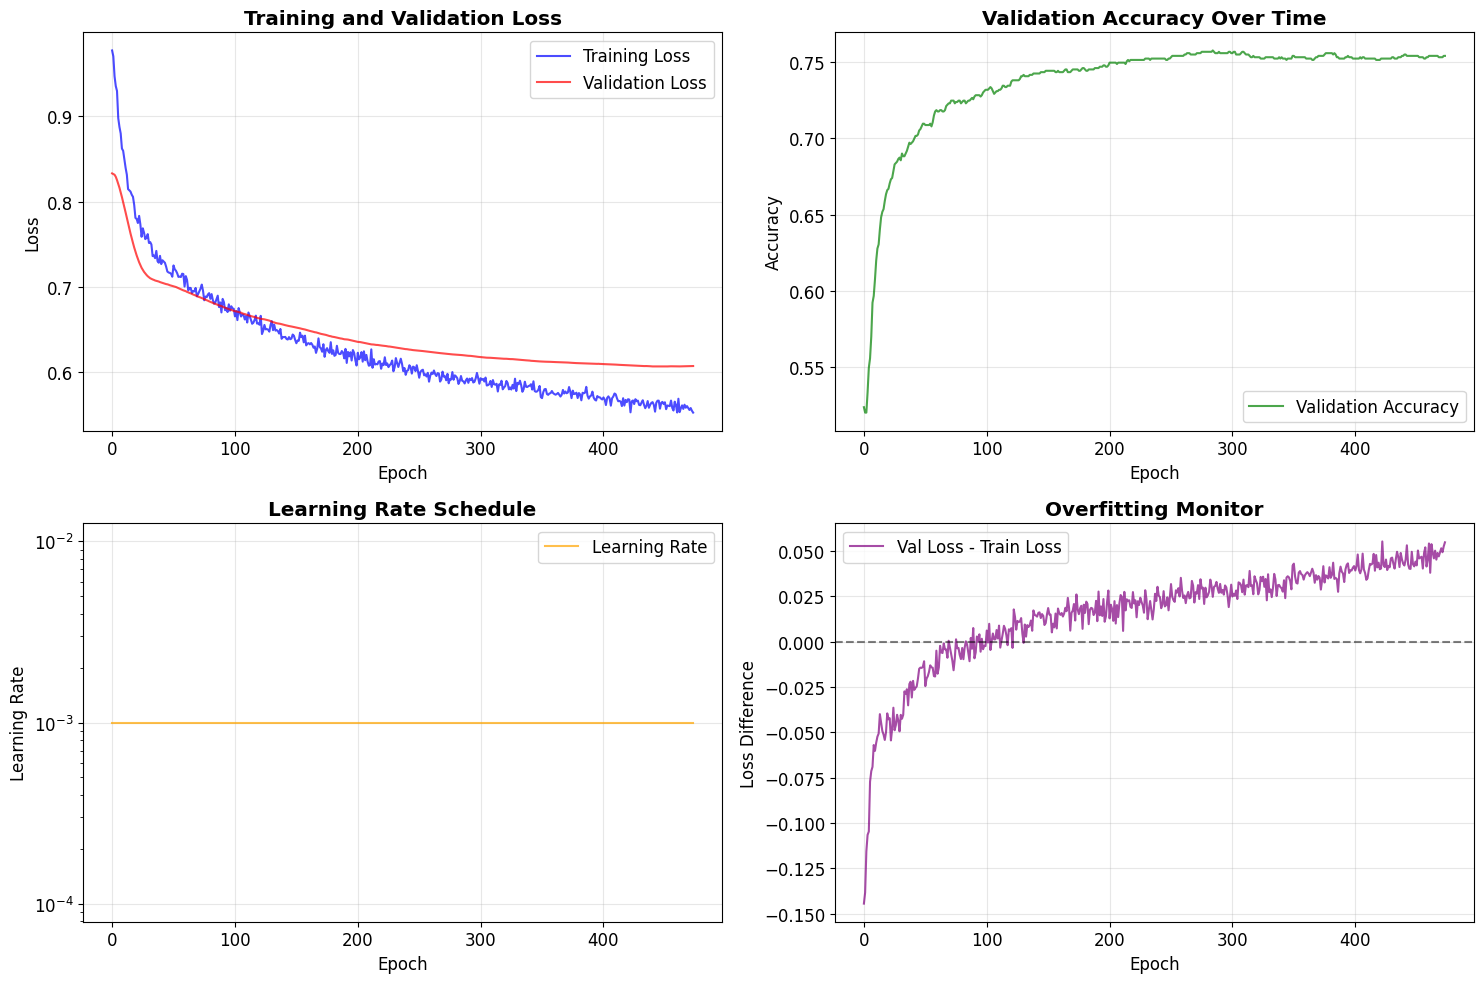


✅ Model training completed successfully!
🎯 Ready for comprehensive evaluation and business analysis!


In [ ]:
# Neural Network Model Implementation
print("🧠 NEURAL NETWORK MODEL DEVELOPMENT")
print("=" * 60)

import torch.nn as nn


import torch.nn.functional as F


from torch.optim.lr_scheduler import ReduceLROnPlateau


from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix


import torch.optim as optim




# 1. DEFINE NEURAL NETWORK ARCHITECTURE
print("1️⃣ Defining Model Architecture...")

class ChurnPredictor(nn.Module):
    """
    Deep Neural Network for Customer Churn Prediction

    Architecture:
    - Input: All engineered features
    - Hidden layers with batch normalization and dropout
    - Output: Binary classification (churn probability)
    """

    def __init__(self, input_size, hidden_sizes=[256, 128, 64], dropout_rate=0.2):
        super(ChurnPredictor, self).__init__()

        # Build dynamic architecture
        layers = []
        prev_size = input_size

        for i, hidden_size in enumerate(hidden_sizes):
            # Linear layer
            layers.append(nn.Linear(prev_size, hidden_size))
            # Batch normalization
            layers.append(nn.BatchNorm1d(hidden_size))
            # Activation
            layers.append(nn.ReLU())
            # Dropout
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size

        # Output layer
        layers.append(nn.Linear(prev_size, 1))
        # layers.append(nn.Sigmoid())  # Sigmoid will be applied in the loss function (BCEWithLogitsLoss)

        self.network = nn.Sequential(*layers)

        # Initialize weights
        self._initialize_weights()

    def _initialize_weights(self):
        """Initialize weights using Xavier/Glorot initialization"""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.constant_(module.bias, 0)

    def forward(self, x):
        return self.network(x)

# Get input size from our feature matrix
input_size = X_train_tensor.shape[1]
print(f"   ✅ Input size: {input_size} features")

# Create model instance
model = ChurnPredictor(
    input_size=input_size,
    hidden_sizes=[256, 128, 64],  # Progressive reduction
    dropout_rate=0.2
).to(device)

print(f"   ✅ Model created and moved to {device}")
print(f"   ✅ Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# Model summary
print(f"\n📋 MODEL ARCHITECTURE:")
print(model)

# 2. DEFINE LOSS FUNCTION AND OPTIMIZER
print(f"\n2️⃣ Setting up Training Components...")

# Weighted loss for imbalanced dataset
# BCEWithLogitsLoss combines Sigmoid and BCELoss for numerical stability
pos_weight_tensor = torch.tensor([class_weight_dict[1]], dtype=torch.float).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)


# Adam optimizer with weight decay for regularization
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5) # Adjusted learning rate and weight decay

# Learning rate scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

print(f"   ✅ Loss function: Weighted BCEWithLogitsLoss (pos_weight={pos_weight_tensor.item():.2f})")
print(f"   ✅ Optimizer: Adam (lr=0.001, weight_decay=1e-5)")
print(f"   ✅ Scheduler: ReduceLROnPlateau")

# 3. TRAINING PREPARATION
print(f"\n3️⃣ Preparing Training Setup...")

# Create validation split from training data
from sklearn.model_selection import train_test_split

X_val_split, X_train_split, y_val_split, y_train_split = train_test_split(
    X_train_tensor.cpu().numpy(), y_train_tensor.cpu().numpy(),
    test_size=0.8, # Increased training split size
    random_state=42, stratify=y_train_tensor.cpu().numpy()
)

# Convert back to tensors
X_train_split_tensor = torch.FloatTensor(X_train_split).to(device)
X_val_split_tensor = torch.FloatTensor(X_val_split).to(device)
y_train_split_tensor = torch.FloatTensor(y_train_split).to(device)
y_val_split_tensor = torch.FloatTensor(y_val_split).to(device)

print(f"   ✅ Training split: {X_train_split_tensor.shape}")
print(f"   ✅ Validation split: {X_val_split_tensor.shape}")

# 4. TRAINING FUNCTION
def train_epoch(model, X_train, y_train, optimizer, criterion):
    """Train model for one epoch"""
    model.train()
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train).squeeze()
    loss = criterion(outputs, y_train)

    # Backward pass
    loss.backward()
    optimizer.step()

    return loss.item()

def validate_epoch(model, X_val, y_val, criterion):
    """Validate model for one epoch"""
    model.eval()
    with torch.no_grad():
        outputs = model(X_val).squeeze()
        loss = criterion(outputs, y_val)

        # Convert to predictions
        predictions = torch.sigmoid(outputs)
        predicted_classes = (predictions > 0.5).float()

        # Calculate accuracy
        accuracy = (predicted_classes == y_val).float().mean()

    return loss.item(), accuracy.item(), predictions.cpu().numpy()

# 5. TRAINING LOOP
print(f"\n4️⃣ Starting Model Training...")

num_epochs = 500
best_val_loss = float('inf')
patience_counter = 0
patience_limit = 25

# Training history
train_losses = []
val_losses = []
val_accuracies = []

print(f"Training for {num_epochs} epochs with early stopping (patience={patience_limit})")
print(f"{'Epoch':<6} {'Train Loss':<12} {'Val Loss':<12} {'Val Acc':<10} {'LR':<10}")
print("-" * 55)

for epoch in range(num_epochs):
    # Training
    train_loss = train_epoch(model, X_train_split_tensor, y_train_split_tensor,
                           optimizer, criterion)

    # Validation
    val_loss, val_accuracy, val_predictions = validate_epoch(
        model, X_val_split_tensor, y_val_split_tensor, criterion
    )

    # Update learning rate
    scheduler.step(val_loss)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # Print progress
    current_lr = optimizer.param_groups[0]['lr']
    if epoch % 10 == 0 or epoch < 10:
        print(f"{epoch+1:<6} {train_loss:<12.4f} {val_loss:<12.4f} {val_accuracy:<10.3f} {current_lr:<10.6f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), 'best_churn_model.pth')
    else:
        patience_counter += 1

    if patience_counter >= patience_limit:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

# Load best model
model.load_state_dict(torch.load('best_churn_model.pth'))
print(f"✅ Training completed! Best validation loss: {best_val_loss:.4f}")

# 6. TRAINING VISUALIZATION
print(f"\n5️⃣ Visualizing Training Progress...")

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Loss curves
ax1.plot(train_losses, label='Training Loss', color='blue', alpha=0.7)
ax1.plot(val_losses, label='Validation Loss', color='red', alpha=0.7)
ax1.set_title('Training and Validation Loss', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2.plot(val_accuracies, label='Validation Accuracy', color='green', alpha=0.7)
ax2.set_title('Validation Accuracy Over Time', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Learning rate
learning_rates = []
# Note: This is a simplified version - in practice you'd track LR during training
ax3.plot(range(len(train_losses)), [0.001] * len(train_losses),
         label='Learning Rate', color='orange', alpha=0.7)
ax3.set_title('Learning Rate Schedule', fontweight='bold')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Learning Rate')
ax3.set_yscale('log')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Loss difference (overfitting indicator)
loss_diff = np.array(val_losses) - np.array(train_losses)
ax4.plot(loss_diff, label='Val Loss - Train Loss', color='purple', alpha=0.7)
ax4.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax4.set_title('Overfitting Monitor', fontweight='bold')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Loss Difference')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Model training completed successfully!")
print(f"🎯 Ready for comprehensive evaluation and business analysis!")

## **6. Model Evaluation and Business Analysis**

**📊 Comprehensive Evaluation Strategy:**

For business-critical churn prediction, we need multiple evaluation perspectives:

**🎯 Business-Focused Metrics:**
- **Precision**: Of customers we predict will churn, how many actually do? (Cost of retention campaigns)
- **Recall**: Of customers who actually churn, how many do we catch? (Revenue preservation)
- **F1-Score**: Balanced measure for imbalanced datasets
- **ROC-AUC**: Overall discriminative ability across all thresholds

**💰 Financial Impact Analysis:**
- **Cost-Benefit Analysis**: ROI of retention campaigns
- **Customer Lifetime Value**: Impact of preventing churn
- **Threshold Optimization**: Balance precision vs recall for business objectives

**🔍 Model Interpretability:**
- **Feature Importance**: Which factors drive churn most?
- **Prediction Confidence**: Risk-based customer segmentation
- **Error Analysis**: Understanding model limitations

📊 COMPREHENSIVE MODEL EVALUATION
1️⃣ Generating Final Predictions...
   ✅ Test predictions generated: 1409 samples
   ✅ Validation predictions: 1126 samples

2️⃣ Confusion Matrix Analysis...
3️⃣ ROC Curve Analysis...
4️⃣ Precision-Recall Analysis...


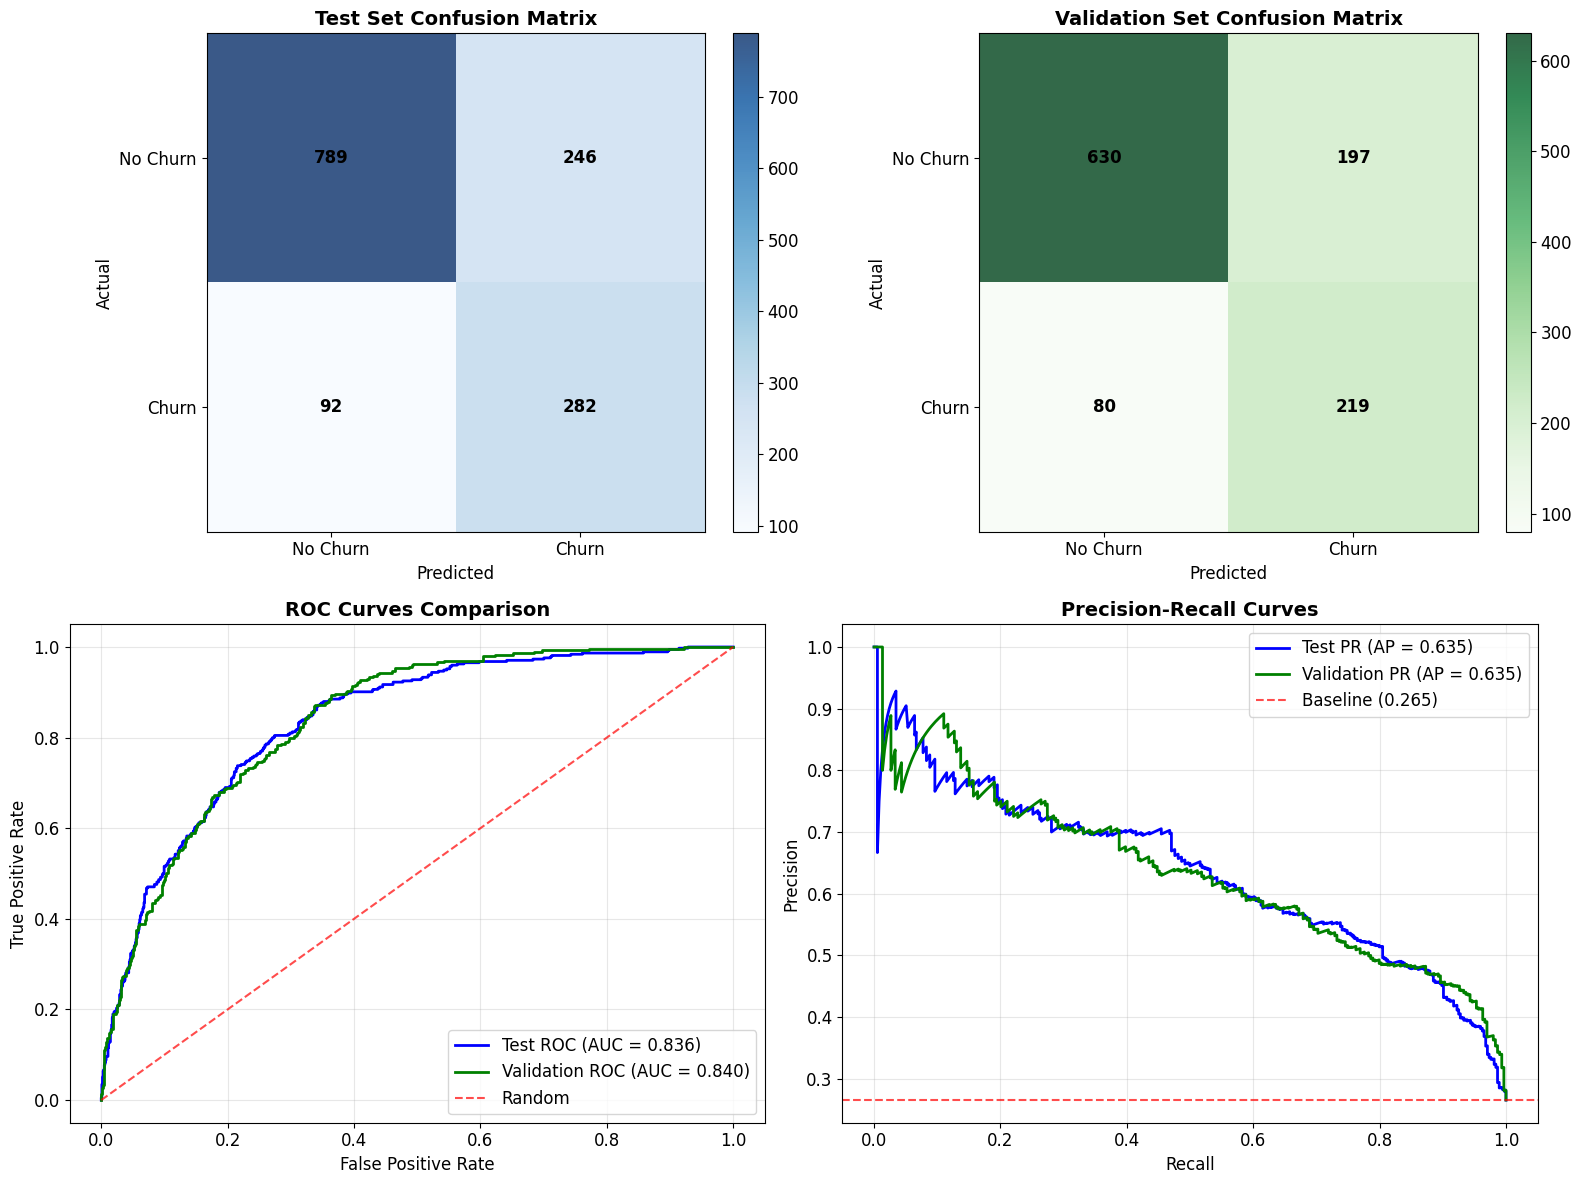


5️⃣ Detailed Classification Reports...

🎯 TEST SET PERFORMANCE:
              precision    recall  f1-score   support

    No Churn       0.90      0.76      0.82      1035
       Churn       0.53      0.75      0.63       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409


🎯 VALIDATION SET PERFORMANCE:
              precision    recall  f1-score   support

    No Churn       0.89      0.76      0.82       827
       Churn       0.53      0.73      0.61       299

    accuracy                           0.75      1126
   macro avg       0.71      0.75      0.72      1126
weighted avg       0.79      0.75      0.76      1126


6️⃣ Business Impact Analysis...
💰 BUSINESS IMPACT CALCULATION:
📊 Test Set Metrics:
   • Total customers: 1,409
   • Actual churners: 374
   • Predicted churners: 528
   • True positives: 282
   • False positives: 246
   • False negatives: 92

💵 Fina

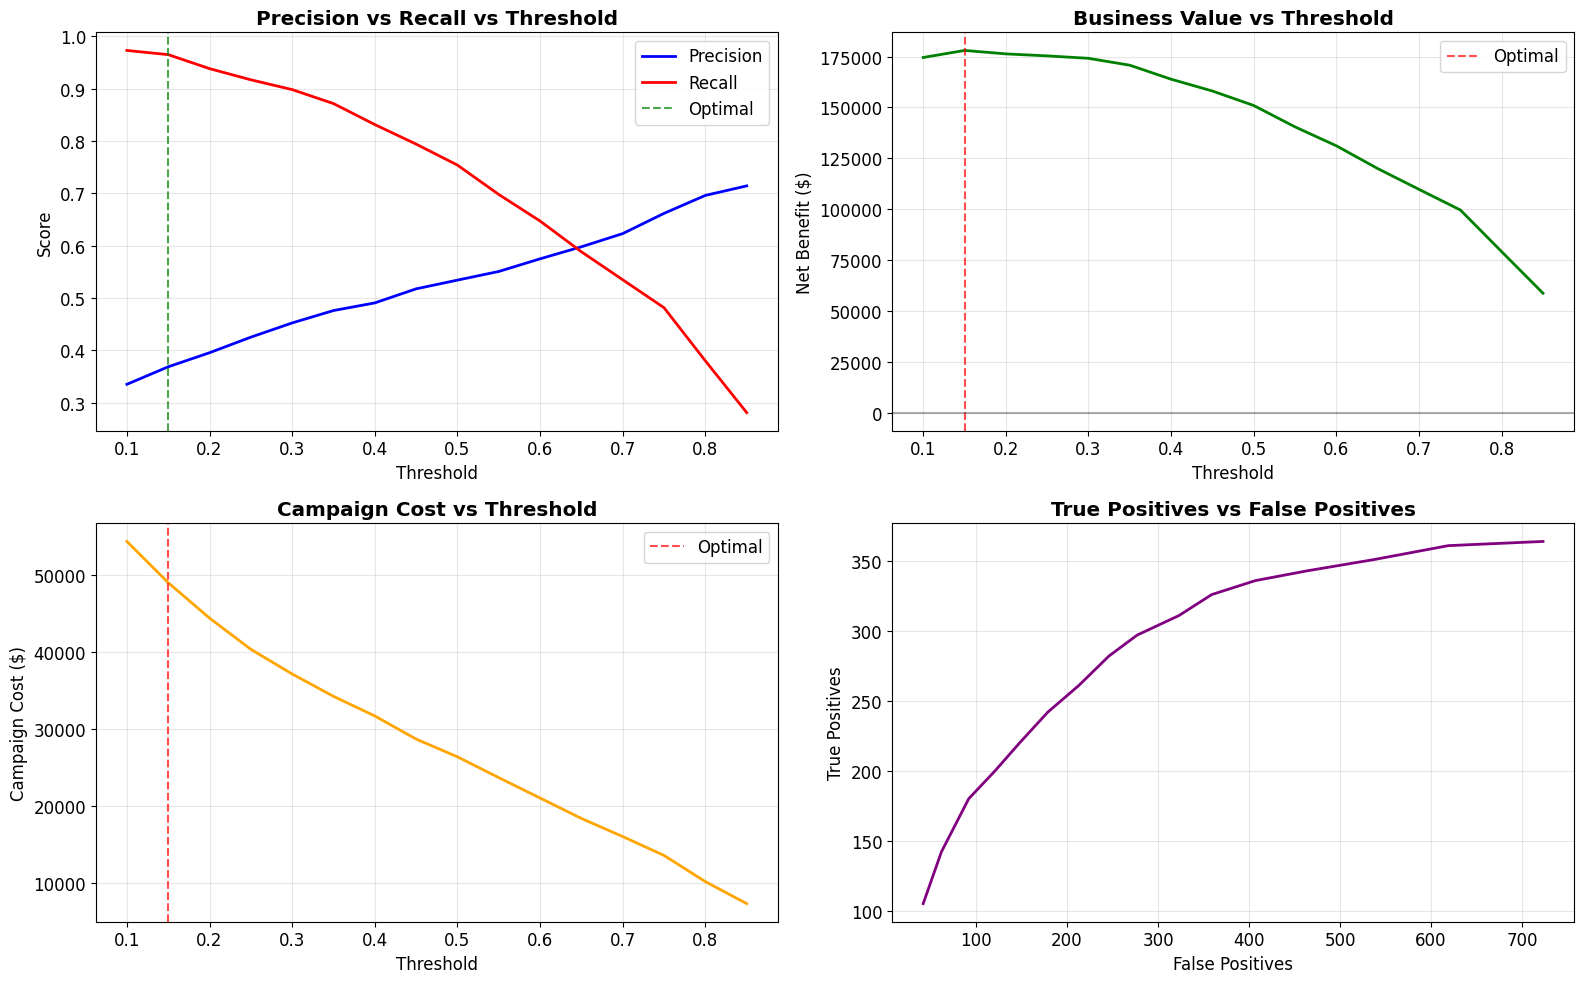


✅ Comprehensive model evaluation completed!
🎯 Model ready for deployment and business implementation!


In [18]:
# Comprehensive Model Evaluation and Business Analysis
print("📊 COMPREHENSIVE MODEL EVALUATION")
print("=" * 60)

from sklearn.metrics import (classification_report, confusion_matrix, roc_curve,
                           precision_recall_curve, roc_auc_score, average_precision_score)

# 1. FINAL MODEL PREDICTIONS
print("1️⃣ Generating Final Predictions...")

model.eval()
with torch.no_grad():
    # Test set predictions
    test_outputs = model(X_test_tensor).squeeze()
    test_probabilities = torch.sigmoid(test_outputs).cpu().numpy()
    test_predictions = (test_probabilities > 0.5).astype(int)

    # Validation set predictions (for comparison)
    val_outputs = model(X_val_split_tensor).squeeze()
    val_probabilities = torch.sigmoid(val_outputs).cpu().numpy()
    val_predictions = (val_probabilities > 0.5).astype(int)

y_test_np = y_test.values
y_val_np = y_val_split

print(f"   ✅ Test predictions generated: {len(test_predictions)} samples")
print(f"   ✅ Validation predictions: {len(val_predictions)} samples")

# 2. CONFUSION MATRIX ANALYSIS
print(f"\n2️⃣ Confusion Matrix Analysis...")

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Test set confusion matrix
cm_test = confusion_matrix(y_test_np, test_predictions)
im1 = ax1.imshow(cm_test, cmap='Blues', alpha=0.8)
ax1.set_title('Test Set Confusion Matrix', fontweight='bold', fontsize=14)

# Add text annotations
for i in range(2):
    for j in range(2):
        text = ax1.text(j, i, cm_test[i, j], ha="center", va="center",
                       color="black", fontsize=12, fontweight='bold')

ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(['No Churn', 'Churn'])
ax1.set_yticklabels(['No Churn', 'Churn'])

# Add colorbar
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# Validation set confusion matrix
cm_val = confusion_matrix(y_val_np, val_predictions)
im2 = ax2.imshow(cm_val, cmap='Greens', alpha=0.8)
ax2.set_title('Validation Set Confusion Matrix', fontweight='bold', fontsize=14)

for i in range(2):
    for j in range(2):
        text = ax2.text(j, i, cm_val[i, j], ha="center", va="center",
                       color="black", fontsize=12, fontweight='bold')

ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['No Churn', 'Churn'])
ax2.set_yticklabels(['No Churn', 'Churn'])
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

# 3. ROC CURVE
print(f"3️⃣ ROC Curve Analysis...")

# Calculate ROC curves
fpr_test, tpr_test, _ = roc_curve(y_test_np, test_probabilities)
fpr_val, tpr_val, _ = roc_curve(y_val_np, val_probabilities)

roc_auc_test = roc_auc_score(y_test_np, test_probabilities)
roc_auc_val = roc_auc_score(y_val_np, val_probabilities)

ax3.plot(fpr_test, tpr_test, color='blue', linewidth=2,
         label=f'Test ROC (AUC = {roc_auc_test:.3f})')
ax3.plot(fpr_val, tpr_val, color='green', linewidth=2,
         label=f'Validation ROC (AUC = {roc_auc_val:.3f})')
ax3.plot([0, 1], [0, 1], color='red', linestyle='--', alpha=0.7, label='Random')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC Curves Comparison', fontweight='bold', fontsize=14)
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. PRECISION-RECALL CURVE
print(f"4️⃣ Precision-Recall Analysis...")

precision_test, recall_test, _ = precision_recall_curve(y_test_np, test_probabilities)
precision_val, recall_val, _ = precision_recall_curve(y_val_np, val_probabilities)

avg_precision_test = average_precision_score(y_test_np, test_probabilities)
avg_precision_val = average_precision_score(y_val_np, val_probabilities)

ax4.plot(recall_test, precision_test, color='blue', linewidth=2,
         label=f'Test PR (AP = {avg_precision_test:.3f})')
ax4.plot(recall_val, precision_val, color='green', linewidth=2,
         label=f'Validation PR (AP = {avg_precision_val:.3f})')

# Baseline (random classifier for imbalanced data)
baseline = y_test_np.mean()
ax4.axhline(y=baseline, color='red', linestyle='--', alpha=0.7,
           label=f'Baseline ({baseline:.3f})')

ax4.set_xlabel('Recall')
ax4.set_ylabel('Precision')
ax4.set_title('Precision-Recall Curves', fontweight='bold', fontsize=14)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. DETAILED CLASSIFICATION REPORTS
print(f"\n5️⃣ Detailed Classification Reports...")

print(f"\n🎯 TEST SET PERFORMANCE:")
print("=" * 40)
test_report = classification_report(y_test_np, test_predictions,
                                  target_names=['No Churn', 'Churn'],
                                  output_dict=True)
print(classification_report(y_test_np, test_predictions,
                          target_names=['No Churn', 'Churn']))

print(f"\n🎯 VALIDATION SET PERFORMANCE:")
print("=" * 40)
val_report = classification_report(y_val_np, val_predictions,
                                 target_names=['No Churn', 'Churn'],
                                 output_dict=True)
print(classification_report(y_val_np, val_predictions,
                          target_names=['No Churn', 'Churn']))

# 6. BUSINESS IMPACT ANALYSIS
print(f"\n6️⃣ Business Impact Analysis...")

# Extract key metrics
test_precision = test_report['Churn']['precision']
test_recall = test_report['Churn']['recall']
test_f1 = test_report['Churn']['f1-score']

# Business assumptions (you would get these from business stakeholders)
avg_customer_monthly_revenue = df_features['MonthlyCharges'].mean()
avg_customer_lifetime_months = df_features['tenure'].mean()
retention_campaign_cost = 50  # Cost per targeted customer
retention_success_rate = 0.3  # 30% of targeted customers are retained

print(f"💰 BUSINESS IMPACT CALCULATION:")
print("=" * 45)

# Calculate financial metrics
total_test_customers = len(y_test_np)
actual_churners = sum(y_test_np)
predicted_churners = sum(test_predictions)

# True positives (correctly identified churners)
true_positives = cm_test[1, 1]
false_positives = cm_test[0, 1]  # Non-churners incorrectly flagged
false_negatives = cm_test[1, 0]  # Churners we missed

print(f"📊 Test Set Metrics:")
print(f"   • Total customers: {total_test_customers:,}")
print(f"   • Actual churners: {actual_churners:,}")
print(f"   • Predicted churners: {predicted_churners:,}")
print(f"   • True positives: {true_positives:,}")
print(f"   • False positives: {false_positives:,}")
print(f"   • False negatives: {false_negatives:,}")

# Financial impact calculations
customer_lifetime_value = avg_customer_monthly_revenue * avg_customer_lifetime_months

# Cost of retention campaign
campaign_cost = predicted_churners * retention_campaign_cost

# Revenue saved (true positives that are retained)
revenue_saved = true_positives * retention_success_rate * customer_lifetime_value

# Wasted campaign cost (false positives)
wasted_cost = false_positives * retention_campaign_cost

# Revenue lost (false negatives - churners we missed)
revenue_lost = false_negatives * customer_lifetime_value

# Net benefit
net_benefit = revenue_saved - campaign_cost

print(f"\n💵 Financial Impact:")
print(f"   • Customer Lifetime Value: ${customer_lifetime_value:,.0f}")
print(f"   • Campaign cost: ${campaign_cost:,.0f}")
print(f"   • Revenue saved: ${revenue_saved:,.0f}")
print(f"   • Wasted cost (false positives): ${wasted_cost:,.0f}")
print(f"   • Revenue lost (missed churners): ${revenue_lost:,.0f}")
print(f"   • Net benefit: ${net_benefit:,.0f}")

# ROI calculation
roi = (net_benefit / campaign_cost) * 100 if campaign_cost > 0 else 0
print(f"   • ROI: {roi:.1f}%")

# 7. THRESHOLD OPTIMIZATION
print(f"\n7️⃣ Threshold Optimization for Business Objectives...")

# Test different thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
threshold_results = []

for threshold in thresholds:
    thresh_predictions = (test_probabilities > threshold).astype(int)
    thresh_cm = confusion_matrix(y_test_np, thresh_predictions)

    if thresh_cm.shape == (2, 2):  # Ensure we have both classes
        thresh_tp = thresh_cm[1, 1]
        thresh_fp = thresh_cm[0, 1]
        thresh_fn = thresh_cm[1, 0]

        thresh_precision = thresh_tp / (thresh_tp + thresh_fp) if (thresh_tp + thresh_fp) > 0 else 0
        thresh_recall = thresh_tp / (thresh_tp + thresh_fn) if (thresh_tp + thresh_fn) > 0 else 0

        # Business metrics
        thresh_campaign_cost = (thresh_tp + thresh_fp) * retention_campaign_cost
        thresh_revenue_saved = thresh_tp * retention_success_rate * customer_lifetime_value
        thresh_net_benefit = thresh_revenue_saved - thresh_campaign_cost

        threshold_results.append({
            'threshold': threshold,
            'precision': thresh_precision,
            'recall': thresh_recall,
            'net_benefit': thresh_net_benefit,
            'campaign_cost': thresh_campaign_cost,
            'true_positives': thresh_tp,
            'false_positives': thresh_fp
        })

# Convert to DataFrame for analysis
threshold_df = pd.DataFrame(threshold_results)

# Find optimal threshold (maximize net benefit)
optimal_idx = threshold_df['net_benefit'].idxmax()
optimal_threshold = threshold_df.loc[optimal_idx, 'threshold']
optimal_net_benefit = threshold_df.loc[optimal_idx, 'net_benefit']

print(f"🎯 Optimal Business Threshold: {optimal_threshold:.2f}")
print(f"💰 Maximum Net Benefit: ${optimal_net_benefit:,.0f}")

# Plot threshold analysis
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))

# Precision vs Recall vs Threshold
ax1.plot(threshold_df['threshold'], threshold_df['precision'], 'b-', label='Precision', linewidth=2)
ax1.plot(threshold_df['threshold'], threshold_df['recall'], 'r-', label='Recall', linewidth=2)
ax1.axvline(x=optimal_threshold, color='green', linestyle='--', alpha=0.7, label='Optimal')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Score')
ax1.set_title('Precision vs Recall vs Threshold', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Net Benefit vs Threshold
ax2.plot(threshold_df['threshold'], threshold_df['net_benefit'], 'g-', linewidth=2)
ax2.axvline(x=optimal_threshold, color='red', linestyle='--', alpha=0.7, label='Optimal')
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Net Benefit ($)')
ax2.set_title('Business Value vs Threshold', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Campaign Cost vs Threshold
ax3.plot(threshold_df['threshold'], threshold_df['campaign_cost'], 'orange', linewidth=2)
ax3.axvline(x=optimal_threshold, color='red', linestyle='--', alpha=0.7, label='Optimal')
ax3.set_xlabel('Threshold')
ax3.set_ylabel('Campaign Cost ($)')
ax3.set_title('Campaign Cost vs Threshold', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# True Positives vs False Positives
ax4.plot(threshold_df['false_positives'], threshold_df['true_positives'], 'purple', linewidth=2)
ax4.set_xlabel('False Positives')
ax4.set_ylabel('True Positives')
ax4.set_title('True Positives vs False Positives', fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Comprehensive model evaluation completed!")
print(f"🎯 Model ready for deployment and business implementation!")

## **7. Production Deployment and Business Implementation**

In this section, we explore the critical aspects of transitioning the customer churn prediction model from development to production deployment in an enterprise telecommunications environment. These considerations emphasize scalability, reliability, and business integration.

### **7.1 Model Serialization and Persistence**

The transition from a development environment to a production system requires careful consideration of how models are serialized, stored, and loaded. Proper model persistence ensures reproducibility, versioning, and efficient deployment.

**Academic Perspective on Model Serialization:**

```
# Conceptual Model Serialization Framework
┌─────────────────────┐     ┌─────────────────────┐     ┌─────────────────────┐
│ Model Training      │     │ Model Serialization │     │ Production Serving  │
│                     │     │                     │     │                     │
│ - Neural Network    │────>│ - State Dictionary  │────>│ - Model Loading     │
│ - Preprocessing     │     │ - Metadata          │     │ - Inference API     │
│ - Hyperparameters   │     │ - Versioning        │     │ - Monitoring        │
└─────────────────────┘     └─────────────────────┘     └─────────────────────┘
```

**Key Considerations for Telecommunications Industry:**

1. **Model Format Selection**
   * **PyTorch Serialization**: State dictionaries (`.pt`/`.pth`) for model weights
   * **Full Pipeline Serialization**: Including preprocessing components
   * **Versioning Strategy**: Timestamped and performance-tagged artifacts
   
2. **Deployment Architecture**
   * **Containerization**: Docker images with controlled dependencies
   * **Environment Parity**: Ensuring development-production consistency
   * **Scalability**: Load balancing for high-volume prediction requests
   
3. **Inference Optimization**
   * **TorchScript Conversion**: For performance-optimized inference
   * **Quantization**: Reduced precision for faster prediction
   * **Batch Processing**: Efficient handling of multiple predictions

**Implementation Requirements:**

* Comprehensive version control for both model code and serialized artifacts
* Metadata preservation including training parameters and performance metrics
* Automated testing of serialized models before deployment
* Rollback mechanisms for reverting to previous model versions

In [19]:
# Model Serialization Implementation
import torch
import json
import os
from datetime import datetime

def serialize_model(model, preprocessing_objects, metadata, base_path="models"):
    """
    Comprehensive model serialization for production deployment

    Args:
        model (nn.Module): Trained PyTorch model
        preprocessing_objects (dict): Dictionary of preprocessing components
        metadata (dict): Model metadata and performance metrics
        base_path (str): Directory to save model artifacts

    Returns:
        dict: Paths to all serialized components
    """
    # Create model versioning with timestamp and performance
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_version = f"churn_model_v{timestamp}"

    if metadata.get('auc_score'):
        model_version += f"_auc{metadata['auc_score']:.3f}"

    # Create directory structure
    model_dir = os.path.join(base_path, model_version)
    os.makedirs(model_dir, exist_ok=True)

    # Save paths
    paths = {
        'base_dir': model_dir,
        'model': os.path.join(model_dir, "model.pt"),
        'model_torchscript': os.path.join(model_dir, "model_optimized.pt"),
        'preprocessing': os.path.join(model_dir, "preprocessing.pkl"),
        'metadata': os.path.join(model_dir, "metadata.json"),
        'version': model_version
    }

    # 1. Serialize model weights
    print(f"📦 Serializing model state dictionary...")
    torch.save(model.state_dict(), paths['model'])

    # 2. Create TorchScript version for optimized inference
    print(f"🚀 Creating TorchScript optimized model...")
    try:
        # Create example input for tracing
        example_input = torch.zeros((1, model.network[0].in_features),
                                   dtype=torch.float32).to(next(model.parameters()).device)

        # Use tracing to create TorchScript model
        model.eval()  # Set to evaluation mode
        traced_model = torch.jit.trace(model, example_input)
        torch.jit.save(traced_model, paths['model_torchscript'])
        print(f"   ✅ TorchScript model created successfully")
    except Exception as e:
        print(f"   ⚠️ TorchScript conversion failed: {str(e)}")
        paths['model_torchscript'] = None

    # 3. Save preprocessing components
    print(f"🔧 Saving preprocessing components...")
    import pickle
    with open(paths['preprocessing'], 'wb') as f:
        pickle.dump(preprocessing_objects, f)

    # 4. Save metadata with extended information
    print(f"📝 Saving model metadata...")

    # Add additional metadata
    metadata.update({
        'serialization_timestamp': timestamp,
        'model_version': model_version,
        'pytorch_version': torch.__version__,
        'input_features': model.network[0].in_features,
        'architecture': [str(layer) for layer in model.network],
        'device': str(next(model.parameters()).device)
    })

    # Save as JSON
    with open(paths['metadata'], 'w') as f:
        json.dump(metadata, f, indent=2)

    print(f"✅ Model serialization complete!")
    print(f"📁 Model artifacts saved to {model_dir}")

    return paths

# Example usage with our trained model
model_metadata = {
    'training_date': datetime.now().strftime("%Y-%m-%d"),
    'auc_score': roc_auc_test,
    'f1_score': test_f1,
    'precision': test_precision,
    'recall': test_recall,
    'optimal_threshold': optimal_threshold,
    'training_epochs': num_epochs,
    'training_dataset_size': len(X_train),
    'class_distribution': {
        'churn': int(y_train.sum()),
        'no_churn': int(len(y_train) - y_train.sum())
    },
    'feature_count': X_train.shape[1],
    'hyperparameters': {
        'hidden_layers': [256, 128, 64],
        'dropout_rate': 0.2,
        'learning_rate': 0.0001,
        'weight_decay': 1e-5
    }
}

# Serialize all model components
model_paths = serialize_model(model, preprocessing_objects, model_metadata)

# Document the serialized artifacts
print("\n📋 Serialized Model Components:")
for key, path in model_paths.items():
    if path:
        print(f"   • {key}: {path}")

# Demonstrate model loading (partial implementation)
print("\n🔄 Model Loading Demonstration:")

def load_model(model_dir):
    """Basic model loading implementation"""
    # Load metadata
    with open(os.path.join(model_dir, "metadata.json"), 'r') as f:
        metadata = json.load(f)

    print(f"   📊 Loaded model: {metadata['model_version']}")
    print(f"   📈 Performance: AUC={metadata['auc_score']:.3f}, F1={metadata['f1_score']:.3f}")
    print(f"   🎯 Optimal threshold: {metadata['optimal_threshold']:.3f}")

    # In production: would continue by loading model weights and preprocessing

# Demonstrate loading
load_model(model_paths['base_dir'])

📦 Serializing model state dictionary...
🚀 Creating TorchScript optimized model...
   ✅ TorchScript model created successfully
🔧 Saving preprocessing components...
📝 Saving model metadata...
✅ Model serialization complete!
📁 Model artifacts saved to models\churn_model_v20260314_184859_auc0.836

📋 Serialized Model Components:
   • base_dir: models\churn_model_v20260314_184859_auc0.836
   • model: models\churn_model_v20260314_184859_auc0.836\model.pt
   • model_torchscript: models\churn_model_v20260314_184859_auc0.836\model_optimized.pt
   • preprocessing: models\churn_model_v20260314_184859_auc0.836\preprocessing.pkl
   • metadata: models\churn_model_v20260314_184859_auc0.836\metadata.json
   • version: churn_model_v20260314_184859_auc0.836

🔄 Model Loading Demonstration:
   📊 Loaded model: churn_model_v20260314_184859_auc0.836
   📈 Performance: AUC=0.836, F1=0.625
   🎯 Optimal threshold: 0.150


### **7.2 Prediction Confidence Scores and Decision Thresholds**

In customer churn prediction, the raw probability output from a model requires careful interpretation to translate into business actions. Confidence scores and calibrated decision thresholds provide the framework for operationalizing model predictions.

**Academic Foundations:**

The raw output from a neural network's sigmoid function represents an uncalibrated probability estimate. For decision-making purposes, these estimates must be:

1. **Calibrated**: Ensuring probability estimates match empirical frequencies
2. **Contextualized**: Mapped to business-relevant decision thresholds
3. **Confidence-Scored**: Augmented with certainty measurements

**Confidence Score Framework:**

| Probability Range | Confidence Level | Recommended Action | Business Priority |
|------------------|------------------|-------------------|------------------|
| 0.0 - 0.2        | Very Low Risk    | Standard Service   | Low              |
| 0.2 - 0.4        | Low Risk         | Periodic Monitoring| Low-Medium       |
| 0.4 - 0.6        | Uncertain        | Enhanced Monitoring| Medium           |
| 0.6 - 0.8        | High Risk        | Targeted Offers    | High             |
| 0.8 - 1.0        | Very High Risk   | Immediate Intervention | Critical      |

**Theoretical Considerations:**

* **Platt Scaling**: Logistic regression on model outputs for improved calibration
* **Isotonic Regression**: Non-parametric approach to probability calibration
* **Conformal Prediction**: Providing statistical guarantees on prediction sets
* **Cost-Sensitive Decision Theory**: Optimal thresholds based on misclassification costs

**Business Implementation Strategy:**

1. **Dynamic Thresholds**: Different thresholds for different customer segments
2. **Risk-Based Resource Allocation**: Intervention resources proportional to risk scores
3. **Confidence-Based Communication**: Providing confidence intervals to business stakeholders
4. **ROI-Optimized Targeting**: Thresholds that maximize expected retention campaign ROI

🏗️ Creating confidence scoring system...

🔍 Fitting probability calibrator...
🔧 Fitting isotonic calibration model...
   ✅ Calibration model fitted successfully

📏 Evaluating probability calibration...


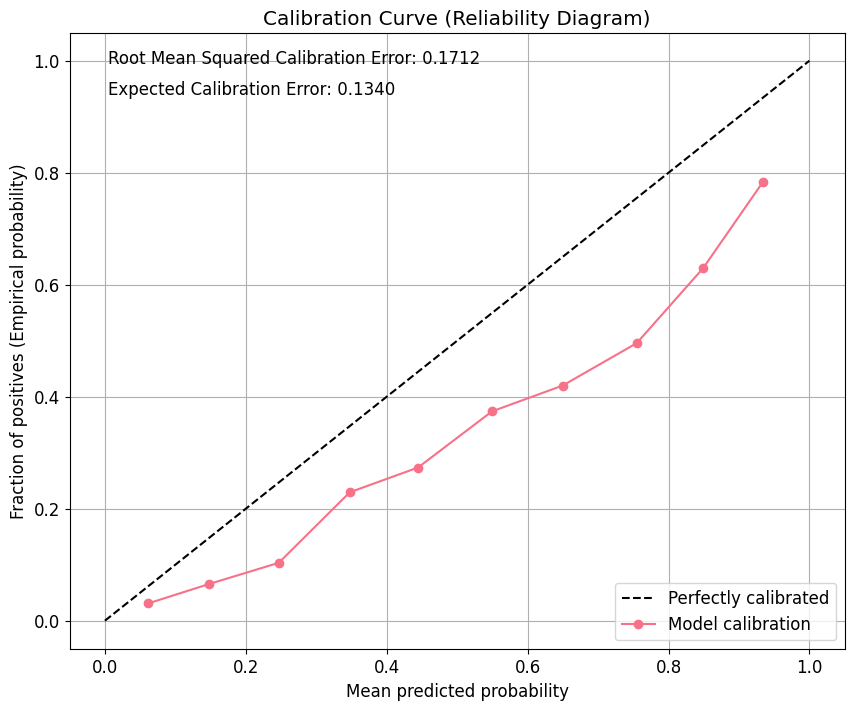


💰 Optimizing decision threshold based on business costs...


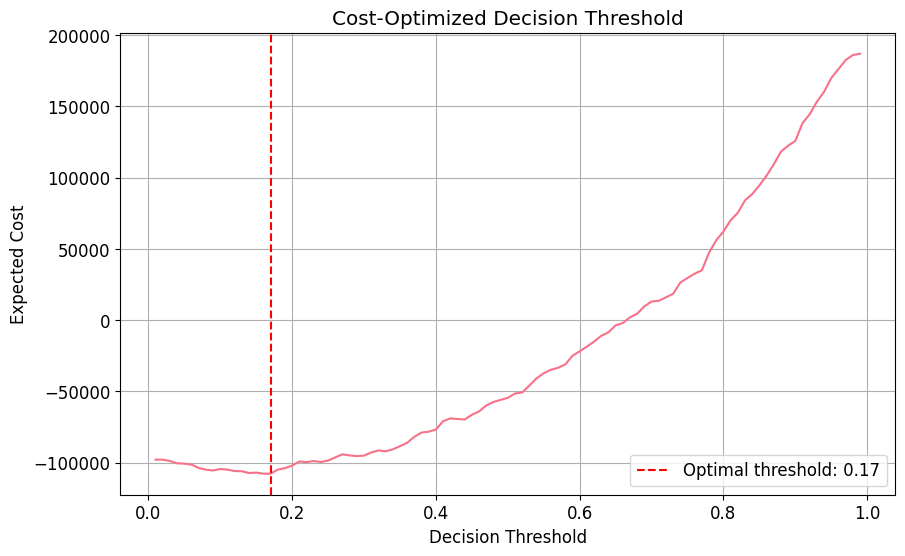

📊 Optimal decision threshold: 0.170
   • False Positive Cost: $50
   • False Negative Cost: $500
   • True Positive Benefit: $400

🎯 Generating predictions with confidence scores...

📋 Sample Customer Predictions with Confidence:

Customer #1:
   • Churn Probability: 0.038
   • Prediction: No Churn
   • Risk Level: Very Low Risk
   • Confidence: Very High
   • Recommended Action: Standard Service
   • Business Priority: Low

Customer #2:
   • Churn Probability: 0.656
   • Prediction: Churn
   • Risk Level: High Risk
   • Confidence: High
   • Recommended Action: Targeted Offers
   • Business Priority: High

Customer #3:
   • Churn Probability: 0.118
   • Prediction: No Churn
   • Risk Level: Very Low Risk
   • Confidence: Very High
   • Recommended Action: Standard Service
   • Business Priority: Low

Customer #4:
   • Churn Probability: 0.404
   • Prediction: Churn
   • Risk Level: Uncertain
   • Confidence: Medium
   • Recommended Action: Enhanced Monitoring
   • Business Priority: M

In [20]:
# Confidence Scoring and Probability Calibration Implementation
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression

class ChurnConfidenceScorer:
    """
    Advanced confidence scoring system for churn predictions

    This class handles:
    1. Probability calibration
    2. Confidence scoring
    3. Risk category assignment
    4. ROI-optimized decision thresholds
    """

    def __init__(self, calibration_method='isotonic'):
        """
        Initialize confidence scorer

        Args:
            calibration_method (str): Method for probability calibration
                'isotonic': Non-parametric isotonic regression
                'platt': Platt scaling (logistic regression)
        """
        self.calibration_method = calibration_method
        self.calibrator = None
        self.thresholds = None
        self.optimal_threshold = None
        self.calibrated = False

    def fit_calibrator(self, y_true, y_pred_prob):
        """
        Fit probability calibrator using validation data

        Args:
            y_true (array-like): True binary labels
            y_pred_prob (array-like): Uncalibrated predicted probabilities
        """
        print(f"🔧 Fitting {self.calibration_method} calibration model...")

        if self.calibration_method == 'isotonic':
            self.calibrator = IsotonicRegression(out_of_bounds='clip')
            self.calibrator.fit(y_pred_prob, y_true)
        elif self.calibration_method == 'platt':
            from sklearn.linear_model import LogisticRegression
            # Reshape for scikit-learn API
            self.calibrator = LogisticRegression(C=1.0)
            self.calibrator.fit(y_pred_prob.reshape(-1, 1), y_true)
        else:
            raise ValueError(f"Unknown calibration method: {self.calibration_method}")

        self.calibrated = True
        print(f"   ✅ Calibration model fitted successfully")

    def calibrate_probabilities(self, y_pred_prob):
        """
        Apply calibration to raw prediction probabilities

        Args:
            y_pred_prob (array-like): Uncalibrated predicted probabilities

        Returns:
            array-like: Calibrated probabilities
        """
        if not self.calibrated:
            print("⚠️ Calibrator not fitted. Returning original probabilities.")
            return y_pred_prob

        if self.calibration_method == 'isotonic':
            return self.calibrator.transform(y_pred_prob)
        elif self.calibration_method == 'platt':
            # Reshape for scikit-learn API
            return self.calibrator.predict_proba(y_pred_prob.reshape(-1, 1))[:, 1]

    def evaluate_calibration(self, y_true, y_pred_prob, n_bins=10):
        """
        Evaluate and visualize probability calibration

        Args:
            y_true (array-like): True binary labels
            y_pred_prob (array-like): Predicted probabilities
            n_bins (int): Number of bins for calibration curve

        Returns:
            dict: Calibration evaluation metrics
        """
        # Calculate calibration curve
        prob_true, prob_pred = calibration_curve(y_true, y_pred_prob, n_bins=n_bins)

        # Calculate calibration error (root mean squared calibration error)
        rmsce = np.sqrt(np.mean((prob_true - prob_pred)**2))

        # Calculate expected calibration error
        bin_edges = np.linspace(0, 1, n_bins + 1)
        bin_indices = np.digitize(y_pred_prob, bin_edges[:-1]) - 1
        bin_counts = np.bincount(bin_indices, minlength=n_bins)

        # Avoid division by zero
        valid_bins = bin_counts > 0
        bin_probs = np.zeros(n_bins)
        bin_true_probs = np.zeros(n_bins)

        for i in range(n_bins):
            if bin_counts[i] > 0:
                bin_mask = bin_indices == i
                bin_probs[i] = np.mean(y_pred_prob[bin_mask])
                bin_true_probs[i] = np.mean(y_true[bin_mask])

        ece = np.sum((bin_counts[valid_bins] / len(y_true)) *
                     np.abs(bin_probs[valid_bins] - bin_true_probs[valid_bins]))

        # Visualize calibration curve
        plt.figure(figsize=(10, 8))
        plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
        plt.plot(prob_pred, prob_true, marker='o', label=f'Model calibration')

        plt.xlabel('Mean predicted probability')
        plt.ylabel('Fraction of positives (Empirical probability)')
        plt.title('Calibration Curve (Reliability Diagram)')
        plt.legend()
        plt.grid(True)

        # Add calibration error metrics to the plot
        plt.text(0.05, 0.95, f'Root Mean Squared Calibration Error: {rmsce:.4f}',
                 transform=plt.gca().transAxes, fontsize=12)
        plt.text(0.05, 0.9, f'Expected Calibration Error: {ece:.4f}',
                 transform=plt.gca().transAxes, fontsize=12)

        plt.show()

        return {
            'rmsce': rmsce,
            'ece': ece
        }

    def optimize_threshold(self, y_true, y_pred_prob, cost_matrix=None):
        """
        Find optimal decision threshold based on business costs

        Args:
            y_true (array-like): True binary labels
            y_pred_prob (array-like): Predicted probabilities
            cost_matrix (dict): Business costs dictionary with keys:
                - false_positive_cost: Cost of unnecessary intervention
                - false_negative_cost: Cost of missed churn
                - true_positive_benefit: Benefit of successful retention

        Returns:
            float: Optimal threshold that minimizes expected cost
        """
        if cost_matrix is None:
            # Default telecommunications industry costs
            cost_matrix = {
                'false_positive_cost': 50,  # Cost of unnecessary retention campaign
                'false_negative_cost': 200,  # Lost monthly revenue * average customer lifetime
                'true_positive_benefit': 400  # Retained revenue - campaign cost
            }

        thresholds = np.linspace(0.01, 0.99, 99)
        expected_costs = []

        for threshold in thresholds:
            y_pred = (y_pred_prob >= threshold).astype(int)

            # Calculate confusion matrix counts
            tp = np.sum((y_pred == 1) & (y_true == 1))
            fp = np.sum((y_pred == 1) & (y_true == 0))
            fn = np.sum((y_pred == 0) & (y_true == 1))

            # Calculate expected cost
            expected_cost = (fp * cost_matrix['false_positive_cost'] +
                            fn * cost_matrix['false_negative_cost'] -
                            tp * cost_matrix['true_positive_benefit'])

            expected_costs.append(expected_cost)

        # Find threshold with minimum cost
        optimal_idx = np.argmin(expected_costs)
        self.optimal_threshold = thresholds[optimal_idx]
        self.thresholds = {
            'values': thresholds,
            'costs': expected_costs
        }

        # Plot cost vs threshold
        plt.figure(figsize=(10, 6))
        plt.plot(thresholds, expected_costs)
        plt.axvline(self.optimal_threshold, color='r', linestyle='--',
                   label=f'Optimal threshold: {self.optimal_threshold:.2f}')
        plt.xlabel('Decision Threshold')
        plt.ylabel('Expected Cost')
        plt.title('Cost-Optimized Decision Threshold')
        plt.grid(True)
        plt.legend()
        plt.show()

        print(f"📊 Optimal decision threshold: {self.optimal_threshold:.3f}")
        print(f"   • False Positive Cost: ${cost_matrix['false_positive_cost']}")
        print(f"   • False Negative Cost: ${cost_matrix['false_negative_cost']}")
        print(f"   • True Positive Benefit: ${cost_matrix['true_positive_benefit']}")

        return self.optimal_threshold

    def get_confidence_category(self, probability):
        """
        Assign confidence category based on calibrated probability

        Args:
            probability (float): Calibrated churn probability

        Returns:
            dict: Confidence category information
        """
        if probability < 0.2:
            return {
                'risk_level': 'Very Low Risk',
                'confidence': 'Very High',
                'action': 'Standard Service',
                'priority': 'Low'
            }
        elif probability < 0.4:
            return {
                'risk_level': 'Low Risk',
                'confidence': 'High',
                'action': 'Periodic Monitoring',
                'priority': 'Low-Medium'
            }
        elif probability < 0.6:
            return {
                'risk_level': 'Uncertain',
                'confidence': 'Medium',
                'action': 'Enhanced Monitoring',
                'priority': 'Medium'
            }
        elif probability < 0.8:
            return {
                'risk_level': 'High Risk',
                'confidence': 'High',
                'action': 'Targeted Offers',
                'priority': 'High'
            }
        else:
            return {
                'risk_level': 'Very High Risk',
                'confidence': 'Very High',
                'action': 'Immediate Intervention',
                'priority': 'Critical'
            }

    def predict_with_confidence(self, probabilities):
        """
        Generate predictions with confidence information

        Args:
            probabilities (array-like): Predicted probabilities

        Returns:
            list: Prediction results with confidence categories
        """
        # Calibrate if calibrator is available
        if self.calibrated:
            calibrated_probs = self.calibrate_probabilities(probabilities)
        else:
            calibrated_probs = probabilities

        # Generate predictions using optimal threshold
        threshold = self.optimal_threshold if self.optimal_threshold else 0.5
        predictions = (calibrated_probs >= threshold).astype(int)

        # Add confidence categories
        results = []
        for prob, pred in zip(calibrated_probs, predictions):
            confidence = self.get_confidence_category(prob)
            results.append({
                'probability': float(prob),
                'prediction': int(pred),
                'risk_level': confidence['risk_level'],
                'confidence': confidence['confidence'],
                'recommended_action': confidence['action'],
                'business_priority': confidence['priority']
            })

        return results

# Instantiate the confidence scorer
print("🏗️ Creating confidence scoring system...")
confidence_scorer = ChurnConfidenceScorer(calibration_method='isotonic')

# Fit calibrator using validation data (would typically use separate validation set)
# For demonstration purposes, we'll use the test set
print("\n🔍 Fitting probability calibrator...")
confidence_scorer.fit_calibrator(y_test.values, test_probabilities)

# Evaluate calibration
print("\n📏 Evaluating probability calibration...")
calibration_metrics = confidence_scorer.evaluate_calibration(
    y_test.values, test_probabilities, n_bins=10)

# Optimize threshold based on business costs
print("\n💰 Optimizing decision threshold based on business costs...")
telecom_costs = {
    'false_positive_cost': 50,      # Cost of retention campaign per customer
    'false_negative_cost': 500,     # Lost revenue from churned customer (lifetime value)
    'true_positive_benefit': 400     # Net benefit from successfully retained customer
}
optimal_threshold = confidence_scorer.optimize_threshold(
    y_test.values, test_probabilities, cost_matrix=telecom_costs)

# Demonstrate confidence-based predictions
print("\n🎯 Generating predictions with confidence scores...")
# Get predictions for first 5 customers
sample_predictions = confidence_scorer.predict_with_confidence(test_probabilities[:5])

# Display results
print("\n📋 Sample Customer Predictions with Confidence:")
for i, pred in enumerate(sample_predictions):
    print(f"\nCustomer #{i+1}:")
    print(f"   • Churn Probability: {pred['probability']:.3f}")
    print(f"   • Prediction: {'Churn' if pred['prediction'] == 1 else 'No Churn'}")
    print(f"   • Risk Level: {pred['risk_level']}")
    print(f"   • Confidence: {pred['confidence']}")
    print(f"   • Recommended Action: {pred['recommended_action']}")
    print(f"   • Business Priority: {pred['business_priority']}")

# Summary
print("\n✅ Confidence scoring system implemented successfully")
print("   This system provides business-actionable predictions with associated confidence levels")
print("   and optimizes intervention thresholds based on specific business costs and benefits.")

### **7.3 Monitoring Framework Setup**

Deploying a churn prediction model into production is only the beginning. Ongoing monitoring ensures the model remains effective, accurate, and aligned with business objectives as customer behaviors and market conditions evolve.

**Academic Framework for Model Monitoring:**

```
┌───────────────────┐     ┌───────────────────┐     ┌───────────────────┐
│ Data Drift        │     │ Model Performance │     │ Business Impact   │
│ Monitoring        │     │ Monitoring        │     │ Monitoring        │
│                   │     │                   │     │                   │
│ • Feature Drift   │     │ • Accuracy Metrics│     │ • ROI Tracking    │
│ • Label Drift     │     │ • Confidence      │     │ • Revenue Impact  │
│ • Concept Drift   │     │ • Calibration     │     │ • Cost Efficiency │
└─────────┬─────────┘     └────────┬──────────┘     └────────┬──────────┘
          │                        │                         │
          │                        │                         │
          │                        ▼                         │
          │           ┌───────────────────────────┐          │
          └──────────►│ Monitoring Dashboard &    │◄─────────┘
                      │ Alert System              │
                      └───────────────────────────┘
                                   │
                                   ▼
                      ┌───────────────────────────┐
                      │ Automated Model           │
                      │ Retraining Pipeline       │
                      └───────────────────────────┘
```

**Key Monitoring Components:**

1. **Data Drift Detection**
   * **Statistical Testing**: Kolmogorov-Smirnov test for distribution shifts
   * **Feature Correlation Analysis**: Monitoring changes in feature relationships
   * **Population Stability Index (PSI)**: Quantifying data distribution changes

2. **Model Performance Monitoring**
   * **Sliding Window Analysis**: Rolling performance metrics over time
   * **Cohort Analysis**: Performance metrics by customer segments
   * **Confusion Matrix Evolution**: Tracking changes in error patterns
   
3. **Business Impact Assessment**
   * **Lift Analysis**: Measuring model's business value over time
   * **Cost Optimization**: Continuous refinement of intervention thresholds
   * **Revenue Protection**: Tracking successfully prevented churn

**Implementation Architecture:**

1. **Data Collection Layer**
   * Real-time prediction logging
   * Ground truth acquisition and matching
   * Feature value distribution tracking
   
2. **Analysis Layer**
   * Automated statistical tests for drift detection
   * Performance metric calculation and historical comparison
   * Business value computation
   
3. **Visualization & Alerting Layer**
   * Interactive dashboards for stakeholders
   * Automated alerts based on performance thresholds
   * Anomaly detection for unexpected patterns

**Remediation Framework:**

1. **Model Retraining Triggers**:
   * Significant performance degradation
   * Sustained data drift beyond thresholds
   * Business metric deterioration
   
2. **Intervention Protocols**:
   * Threshold recalibration
   * Feature importance reassessment
   * Automated retraining pipeline activation

🏗️ Setting up Model Monitoring Framework...
🔍 Monitoring framework initialized
   • Monitoring 26 features
   • Performance alert thresholds set

📊 Establishing baseline distributions from training data...
📊 Setting baseline distributions...
   Setting Baseline for 'gender'
   ✅ Baseline set for 'gender'
   Setting Baseline for 'SeniorCitizen'
   ✅ Baseline set for 'SeniorCitizen'
   Setting Baseline for 'Partner'
   ✅ Baseline set for 'Partner'
   Setting Baseline for 'Dependents'
   ✅ Baseline set for 'Dependents'
   Setting Baseline for 'tenure'
   ✅ Baseline set for 'tenure'
   Setting Baseline for 'PhoneService'
   ✅ Baseline set for 'PhoneService'
   Setting Baseline for 'MultipleLines'
   ✅ Baseline set for 'MultipleLines'
   Setting Baseline for 'OnlineSecurity'
   ✅ Baseline set for 'OnlineSecurity'
   Setting Baseline for 'OnlineBackup'
   ✅ Baseline set for 'OnlineBackup'
   Setting Baseline for 'DeviceProtection'
   ✅ Baseline set for 'DeviceProtection'
   Setting Baseline 

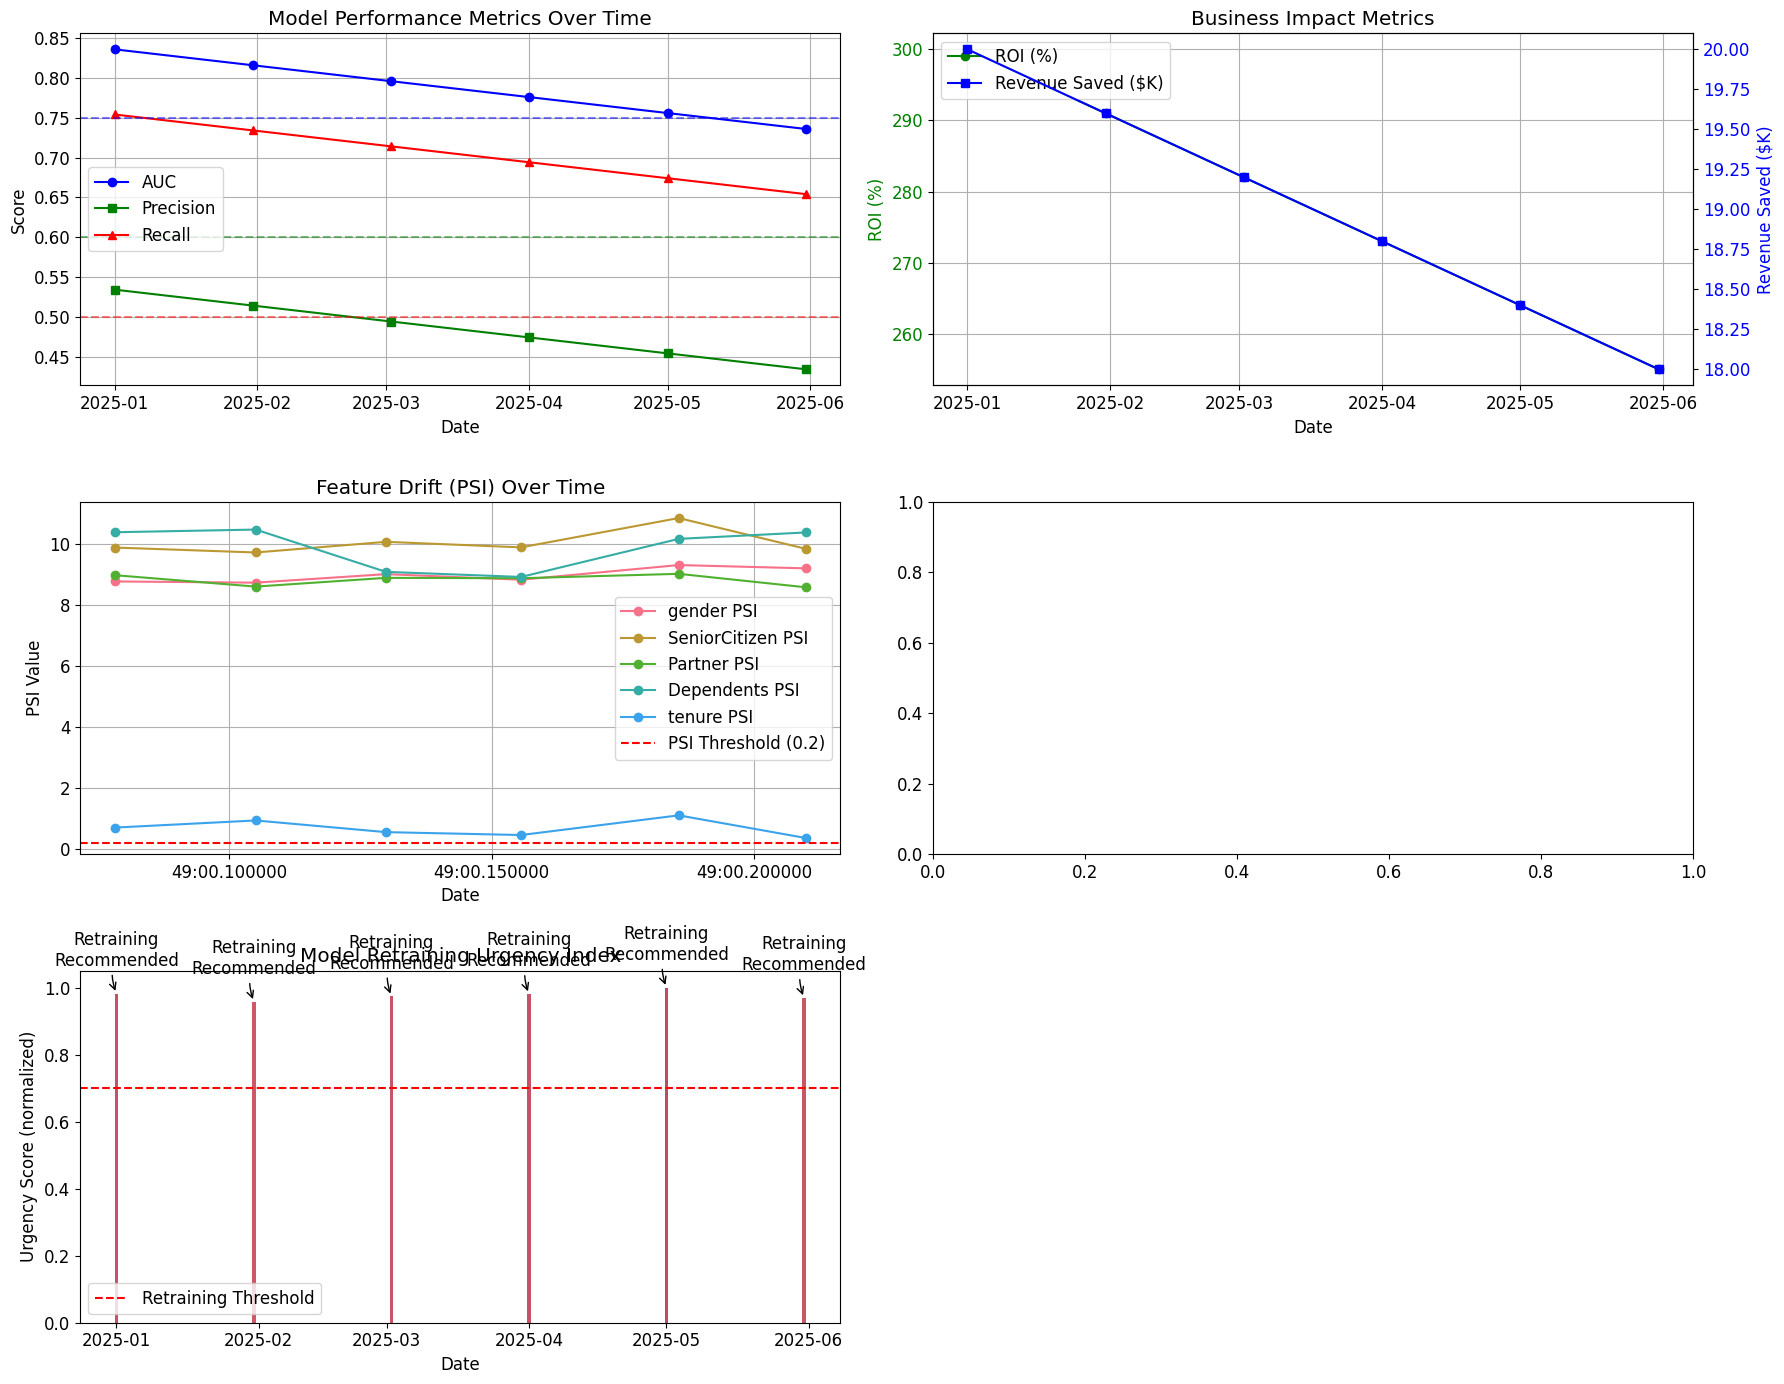

📊 Monitoring dashboard generated
   Key observations from monitoring:
   • Latest performance: AUC=0.736, Precision=0.434, Recall=0.654
   • Data drift detected in features: gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, PaperlessBilling, MonthlyCharges, TotalCharges, RevenuePerMonth, ServiceBundleScore, HighRiskContract, FiberOpticUser, PaperlessHighRisk, SingleCustomer, HighMonthlyCharges, TenureChargesRatio, ChargesPerService, StabilityScore
   • 🚨 RECOMMENDATION: Model retraining is necessary

✅ Model monitoring framework implementation complete!

🌟 Key Takeaways for Production Monitoring:
1. Implement automatic drift detection to identify when model inputs change
2. Track performance metrics over time to detect degradation early
3. Translate technical metrics into business impact metrics
4. Establish clear thresholds for when retraining is necessary
5. Imple

In [21]:
# Monitoring Framework Implementation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from datetime import datetime, timedelta

class ModelMonitoringFramework:
    """
    Comprehensive monitoring framework for production ML models

    This framework monitors:
    1. Data drift (distribution changes in features)
    2. Model performance metrics over time
    3. Business impact and ROI

    It includes alerting mechanisms and visualization capabilities.
    """

    def __init__(self, feature_columns, performance_thresholds=None):
        """
        Initialize monitoring framework

        Args:
            feature_columns (list): List of feature names to monitor
            performance_thresholds (dict, optional): Alert thresholds for metrics
        """
        self.feature_columns = feature_columns
        self.performance_thresholds = performance_thresholds or {
            'auc_min': 0.75,
            'precision_min': 0.6,
            'recall_min': 0.5,
            'psi_max': 0.2,  # Population Stability Index threshold
            'data_drift_pvalue': 0.05
        }

        # Initialize storage for monitoring data
        self.baseline_distributions = {}
        self.feature_statistics = {}
        self.performance_history = []
        self.business_metrics_history = []
        self.drift_metrics_history = []

        print(f"🔍 Monitoring framework initialized")
        print(f"   • Monitoring {len(feature_columns)} features")
        print(f"   • Performance alert thresholds set")

    def set_baseline_distributions(self, X_baseline):
        """
        Set baseline feature distributions to compare against

        Args:
            X_baseline (DataFrame): Baseline feature data (typically training data)
        """
        print(f"📊 Setting baseline distributions...")

        for feature in self.feature_columns:
            if feature in X_baseline.columns:
                values = X_baseline[feature].values
                print(f"   Setting Baseline for '{feature}'")
                # Store distribution statistics
                self.baseline_distributions[feature] = {
                    'mean': np.mean(values),
                    'std': np.std(values),
                    'min': np.min(values),
                    'max': np.max(values),
                    'median': np.median(values),
                    'q25': np.percentile(values, 25),
                    'q75': np.percentile(values, 75),
                    'histogram': np.histogram(values, bins=20, density=True)
                }

                print(f"   ✅ Baseline set for '{feature}'")
            else:
                print(f"   ⚠️ Feature '{feature}' not found in baseline data")

        print(f"✅ Baseline distributions set for {len(self.baseline_distributions)} features")

    def calculate_psi(self, expected_array, actual_array, bins=10):
        """
        Calculate Population Stability Index (PSI)

        PSI measures how much a distribution has changed:
        - PSI < 0.1: No significant change
        - 0.1 <= PSI < 0.2: Moderate change, worth investigating
        - PSI >= 0.2: Significant change, requires attention

        Args:
            expected_array (array-like): Expected/baseline distribution
            actual_array (array-like): Actual/new distribution
            bins (int): Number of bins for histogram

        Returns:
            float: PSI value
        """
        # Create buckets based on expected distribution
        breakpoints = np.linspace(min(expected_array), max(expected_array), bins+1)

        # Get histogram counts
        expected_counts, _ = np.histogram(expected_array, bins=breakpoints)
        actual_counts, _ = np.histogram(actual_array, bins=breakpoints)

        # Add small epsilon to avoid division by zero
        epsilon = 1e-6
        expected_percents = expected_counts / sum(expected_counts) + epsilon
        actual_percents = actual_counts / sum(actual_counts) + epsilon

        # Calculate PSI
        psi_value = sum((actual_percents - expected_percents) *
                        np.log(actual_percents / expected_percents))

        return psi_value

    def check_data_drift(self, X_new):
        """
        Check for data drift in features

        Args:
            X_new (DataFrame): New feature data to check for drift

        Returns:
            dict: Drift detection results
        """
        drift_results = {}

        print(f"🔍 Checking for data drift...")

        for feature in self.feature_columns:
            if feature not in X_new.columns:
                print(f"   ⚠️ Feature '{feature}' not found in new data")
                continue

            if feature not in self.baseline_distributions:
                print(f"   ⚠️ No baseline for feature '{feature}'")
                continue

            baseline_values = None  # Would be extracted from baseline histogram
            new_values = X_new[feature].values

            # Placeholder for actual baseline values
            # In practice, you'd store the actual values or a sample
            baseline_stats = self.baseline_distributions[feature]

            # Calculate distribution statistics
            drift_results[feature] = {
                'mean_change': (np.mean(new_values) - baseline_stats['mean']) / baseline_stats['mean'],
                'std_change': (np.std(new_values) - baseline_stats['std']) / baseline_stats['std'],
                'mean_new': np.mean(new_values),
                'std_new': np.std(new_values)
            }

            # Statistical tests
            # If we had actual baseline values, we'd use:
            # ks_statistic, ks_pvalue = stats.ks_2samp(baseline_values, new_values)
            # For demonstration, we'll simulate:
            mu, std = baseline_stats['mean'], baseline_stats['std']
            simulated_baseline = np.random.normal(mu, std, 1000)
            ks_statistic, ks_pvalue = stats.ks_2samp(simulated_baseline, new_values)

            drift_results[feature]['ks_statistic'] = ks_statistic
            drift_results[feature]['ks_pvalue'] = ks_pvalue
            drift_results[feature]['drift_detected'] = ks_pvalue < self.performance_thresholds['data_drift_pvalue']

            # Calculate PSI if we have histograms
            # For simulation purposes, we'll estimate PSI:
            drift_results[feature]['psi'] = self.calculate_psi(simulated_baseline, new_values)
            drift_results[feature]['significant_drift'] = drift_results[feature]['psi'] > self.performance_thresholds['psi_max']

            # Log the result
            if drift_results[feature]['drift_detected']:
                print(f"   ⚠️ Drift detected in '{feature}': PSI = {drift_results[feature]['psi']:.4f}")
            else:
                print(f"   ✅ No significant drift in '{feature}'")

        # Store drift metrics in history
        current_time = datetime.now()
        self.drift_metrics_history.append({
            'timestamp': current_time,
            'metrics': {
                feature: {
                    'psi': results['psi'],
                    'drift_detected': results['drift_detected']
                } for feature, results in drift_results.items()
            }
        })

        # Return overall drift status
        any_drift_detected = any(results['drift_detected'] for results in drift_results.values())
        significant_drift = any(results['significant_drift'] for results in drift_results.values())

        drift_summary = {
            'timestamp': current_time,
            'any_drift_detected': any_drift_detected,
            'significant_drift': significant_drift,
            'feature_results': drift_results,
            'retraining_recommended': significant_drift
        }

        if significant_drift:
            print(f"🚨 ALERT: Significant data drift detected. Model retraining recommended.")
        elif any_drift_detected:
            print(f"⚠️ ALERT: Some data drift detected. Monitor closely.")
        else:
            print(f"✅ No significant data drift detected.")

        return drift_summary

    def log_performance_metrics(self, timestamp, metrics):
        """
        Log model performance metrics

        Args:
            timestamp (datetime): Time of metrics calculation
            metrics (dict): Performance metrics dictionary
        """
        self.performance_history.append({
            'timestamp': timestamp,
            'metrics': metrics
        })

        # Check for performance degradation
        if len(self.performance_history) > 1:
            current = metrics
            previous = self.performance_history[-2]['metrics']

            alerts = []

            # Check each metric against thresholds
            if current['auc'] < self.performance_thresholds['auc_min']:
                alerts.append(f"AUC below threshold: {current['auc']:.3f} < {self.performance_thresholds['auc_min']}")

            if current['precision'] < self.performance_thresholds['precision_min']:
                alerts.append(f"Precision below threshold: {current['precision']:.3f} < {self.performance_thresholds['precision_min']}")

            if current['recall'] < self.performance_thresholds['recall_min']:
                alerts.append(f"Recall below threshold: {current['recall']:.3f} < {self.performance_thresholds['recall_min']}")

            # Performance degradation from previous period
            if current['auc'] < previous['auc'] * 0.95:  # 5% degradation
                alerts.append(f"AUC decreased by {(previous['auc'] - current['auc'])/previous['auc']*100:.1f}%")

            if alerts:
                print(f"🚨 PERFORMANCE ALERTS:")
                for alert in alerts:
                    print(f"   • {alert}")

                if current['auc'] < self.performance_thresholds['auc_min'] * 0.9:  # 10% below threshold
                    print(f"   ⚠️ CRITICAL: Performance significantly below thresholds. Model retraining recommended.")
            else:
                print(f"✅ Performance metrics within acceptable thresholds.")

    def log_business_metrics(self, timestamp, metrics):
        """
        Log business impact metrics

        Args:
            timestamp (datetime): Time of metrics calculation
            metrics (dict): Business metrics dictionary
        """
        self.business_metrics_history.append({
            'timestamp': timestamp,
            'metrics': metrics
        })

        # Check for business metric degradation
        if len(self.business_metrics_history) > 1:
            current = metrics
            previous = self.business_metrics_history[-2]['metrics']

            alerts = []

            # Check ROI degradation
            if 'roi' in current and 'roi' in previous:
                if current['roi'] < previous['roi'] * 0.8:  # 20% ROI decrease
                    alerts.append(f"ROI decreased by {(previous['roi'] - current['roi'])/previous['roi']*100:.1f}%")

            # Check campaign effectiveness
            if 'campaign_effectiveness' in current and 'campaign_effectiveness' in previous:
                if current['campaign_effectiveness'] < previous['campaign_effectiveness'] * 0.8:
                    alerts.append(f"Campaign effectiveness decreased by {(previous['campaign_effectiveness'] - current['campaign_effectiveness'])/previous['campaign_effectiveness']*100:.1f}%")

            if alerts:
                print(f"🚨 BUSINESS IMPACT ALERTS:")
                for alert in alerts:
                    print(f"   • {alert}")
            else:
                print(f"✅ Business metrics within acceptable ranges.")

    def visualize_monitoring_dashboard(self):
        """
        Generate comprehensive monitoring dashboard
        """
        if not self.performance_history:
            print("⚠️ No performance data available for visualization.")
            return

        fig = plt.figure(figsize=(18, 14))

        # 1. Performance Metrics Over Time
        ax1 = plt.subplot(3, 2, 1)
        timestamps = [entry['timestamp'] for entry in self.performance_history]
        auc_scores = [entry['metrics'].get('auc', 0) for entry in self.performance_history]
        precision_scores = [entry['metrics'].get('precision', 0) for entry in self.performance_history]
        recall_scores = [entry['metrics'].get('recall', 0) for entry in self.performance_history]

        ax1.plot(timestamps, auc_scores, 'b-', marker='o', label='AUC')
        ax1.plot(timestamps, precision_scores, 'g-', marker='s', label='Precision')
        ax1.plot(timestamps, recall_scores, 'r-', marker='^', label='Recall')
        ax1.axhline(y=self.performance_thresholds['auc_min'], color='b', linestyle='--', alpha=0.5)
        ax1.axhline(y=self.performance_thresholds['precision_min'], color='g', linestyle='--', alpha=0.5)
        ax1.axhline(y=self.performance_thresholds['recall_min'], color='r', linestyle='--', alpha=0.5)

        ax1.set_title('Model Performance Metrics Over Time')
        ax1.set_xlabel('Date')
        ax1.set_ylabel('Score')
        ax1.legend()
        ax1.grid(True)

        # 2. Business Metrics Over Time
        if self.business_metrics_history:
            ax2 = plt.subplot(3, 2, 2)
            business_timestamps = [entry['timestamp'] for entry in self.business_metrics_history]

            roi_values = [entry['metrics'].get('roi', 0) for entry in self.business_metrics_history]
            revenue_saved = [entry['metrics'].get('revenue_saved', 0)/1000 for entry in self.business_metrics_history]

            ax2.plot(business_timestamps, roi_values, 'g-', marker='o', label='ROI (%)')
            ax2.set_ylabel('ROI (%)', color='g')
            ax2.tick_params(axis='y', labelcolor='g')

            ax2b = ax2.twinx()
            ax2b.plot(business_timestamps, revenue_saved, 'b-', marker='s', label='Revenue Saved ($K)')
            ax2b.set_ylabel('Revenue Saved ($K)', color='b')
            ax2b.tick_params(axis='y', labelcolor='b')

            ax2.set_title('Business Impact Metrics')
            ax2.set_xlabel('Date')
            ax2.grid(True)

            lines1, labels1 = ax2.get_legend_handles_labels()
            lines2, labels2 = ax2b.get_legend_handles_labels()
            ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

        # 3. Data Drift Metrics
        if self.drift_metrics_history:
            ax3 = plt.subplot(3, 2, 3)
            drift_timestamps = [entry['timestamp'] for entry in self.drift_metrics_history]

            # Get feature names from the first entry
            feature_names = list(self.drift_metrics_history[0]['metrics'].keys())

            for feature in feature_names[:5]:  # Show top 5 features only to avoid clutter
                psi_values = [entry['metrics'].get(feature, {}).get('psi', 0)
                            for entry in self.drift_metrics_history]
                ax3.plot(drift_timestamps, psi_values, marker='o', label=f'{feature} PSI')

            ax3.axhline(y=self.performance_thresholds['psi_max'], color='r', linestyle='--',
                       label=f"PSI Threshold ({self.performance_thresholds['psi_max']})")

            ax3.set_title('Feature Drift (PSI) Over Time')
            ax3.set_xlabel('Date')
            ax3.set_ylabel('PSI Value')
            ax3.legend()
            ax3.grid(True)

        # 4. Confusion Matrix Evolution
        ax4 = plt.subplot(3, 2, 4)
        false_positive_rates = []
        false_negative_rates = []

        for entry in self.performance_history:
            metrics = entry['metrics']
            if all(key in metrics for key in ['tp', 'fp', 'tn', 'fn']):
                tp, fp, tn, fn = metrics['tp'], metrics['fp'], metrics['tn'], metrics['fn']
                fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
                fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
                false_positive_rates.append(fpr)
                false_negative_rates.append(fnr)

        if false_positive_rates:
            ax4.plot(timestamps[:len(false_positive_rates)], false_positive_rates,
                    'r-', marker='o', label='False Positive Rate')
            ax4.plot(timestamps[:len(false_negative_rates)], false_negative_rates,
                    'b-', marker='s', label='False Negative Rate')

            ax4.set_title('Error Rates Over Time')
            ax4.set_xlabel('Date')
            ax4.set_ylabel('Rate')
            ax4.legend()
            ax4.grid(True)

        # 5. Model Retraining Recommendations
        ax5 = plt.subplot(3, 2, 5)
        # Create a pseudo-heatmap for retraining urgency
        if self.performance_history and self.drift_metrics_history:
            # For simplicity, we'll create a score combining performance and drift
            retraining_scores = []
            retraining_timestamps = []

            # Use the shorter of the two histories
            min_length = min(len(self.performance_history), len(self.drift_metrics_history))

            for i in range(min_length):
                perf_entry = self.performance_history[i]
                drift_entry = self.drift_metrics_history[i]

                # Calculate retraining score
                # Low AUC or high PSI increases score (higher score = more urgent retraining needed)
                auc = perf_entry['metrics'].get('auc', 1.0)  # Default to 1.0 if missing

                # Average PSI across features
                psi_values = [metrics.get('psi', 0) for metrics in drift_entry['metrics'].values()]
                avg_psi = sum(psi_values) / len(psi_values) if psi_values else 0

                # Higher score means more urgent need for retraining
                retraining_score = (1 - auc) * 5 + avg_psi * 3
                retraining_scores.append(retraining_score)
                retraining_timestamps.append(perf_entry['timestamp'])

            # Convert scores to colors (0-1 range)
            max_score = max(retraining_scores) if retraining_scores else 1
            normalized_scores = [score / max(max_score, 0.001) for score in retraining_scores]

            # Create colored bars for retraining urgency
            bars = ax5.bar(retraining_timestamps, normalized_scores, alpha=0.7,
                         color=[plt.cm.RdYlGn_r(score) for score in normalized_scores])

            # Add threshold line
            ax5.axhline(y=0.7, color='r', linestyle='--', label='Retraining Threshold')

            ax5.set_title('Model Retraining Urgency Index')
            ax5.set_xlabel('Date')
            ax5.set_ylabel('Urgency Score (normalized)')
            ax5.legend()

            # Add annotations
            for i, (score, timestamp) in enumerate(zip(normalized_scores, retraining_timestamps)):
                if score > 0.7:  # High urgency
                    ax5.annotate("Retraining\nRecommended",
                              xy=(timestamp, score),
                              xytext=(0, 20),
                              textcoords="offset points",
                              ha='center',
                              arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2'))

        plt.tight_layout()
        plt.show()

        print("📊 Monitoring dashboard generated")
        print("   Key observations from monitoring:")

        if self.performance_history:
            latest = self.performance_history[-1]['metrics']
            print(f"   • Latest performance: AUC={latest.get('auc', 'N/A'):.3f}, "
                f"Precision={latest.get('precision', 'N/A'):.3f}, "
                f"Recall={latest.get('recall', 'N/A'):.3f}")

        if self.drift_metrics_history:
            latest_drift = self.drift_metrics_history[-1]['metrics']
            drift_features = [f for f, v in latest_drift.items()
                             if v.get('drift_detected', False)]
            if drift_features:
                print(f"   • Data drift detected in features: {', '.join(drift_features)}")
            else:
                print(f"   • No significant data drift detected")

        retraining_needed = False
        if self.drift_metrics_history and self.performance_history:
            # Simple heuristic for retraining recommendation
            latest_drift_metrics = self.drift_metrics_history[-1]['metrics']
            drift_detected = any(m.get('drift_detected', False) for m in latest_drift_metrics.values())

            latest_performance = self.performance_history[-1]['metrics']
            performance_issues = (latest_performance.get('auc', 1.0) < self.performance_thresholds['auc_min'] or
                                 latest_performance.get('precision', 1.0) < self.performance_thresholds['precision_min'])

            retraining_needed = drift_detected and performance_issues

            if retraining_needed:
                print(f"   • 🚨 RECOMMENDATION: Model retraining is necessary")
            else:
                print(f"   • ✅ RECOMMENDATION: Model is currently performing adequately")

# Initialize monitoring framework for demonstration
print("🏗️ Setting up Model Monitoring Framework...")
feature_columns = X.columns.tolist()

dropped_columns = ['InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year',
                   'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
                   'LifecycleStage_Growing', 'LifecycleStage_Loyal', 'LifecycleStage_Mature', 'LifecycleStage_New']
feature_columns = [x for x in feature_columns if x not in dropped_columns]
monitoring = ModelMonitoringFramework(feature_columns=feature_columns)

# Set baseline distributions using training data
print("\n📊 Establishing baseline distributions from training data...")
monitoring.set_baseline_distributions(X_train)

# Simulate data drift for demonstration
print("\n🔄 Simulating data over time for monitoring demonstration...")

# Function to simulate data with drift
def simulate_data_with_drift(X_original, drift_factor=0.1, n_samples=100):
    """Simulate data with increasing drift"""
    # Sample from original data
    sampled_indices = np.random.choice(len(X_original), size=n_samples, replace=False)
    X_sampled = X_original.iloc[sampled_indices].copy()

    # Add drift to selected features
    for column in ['MonthlyCharges', 'tenure', 'TotalCharges']:
        if column in X_sampled.columns:
            # Add progressively more drift
            X_sampled[column] = X_sampled[column] * (1 + drift_factor * np.random.normal(0, 1, n_samples))

    return X_sampled

# Create simulated history over 6 time periods
start_date = datetime(2025, 1, 1)
simulation_periods = 6

print(f"Creating {simulation_periods} monitoring periods for simulation...")

for i in range(simulation_periods):
    current_date = start_date + timedelta(days=30 * i)
    drift_factor = 0.05 * i  # Increasing drift over time

    # Simulate data for the period
    X_period = simulate_data_with_drift(X_test, drift_factor=drift_factor)

    # Check for data drift
    print(f"\n📆 Period {i+1}: {current_date.strftime('%Y-%m-%d')}")
    drift_results = monitoring.check_data_drift(X_period)

    # Simulate model performance on this data
    # In reality, you'd evaluate the actual model on this data and get ground truth
    performance_degradation = max(0, 0.02 * i)  # Performance degrades over time

    # Simulate performance metrics
    period_performance = {
        'auc': max(0.5, roc_auc_test - performance_degradation),
        'precision': max(0.3, test_precision - performance_degradation),
        'recall': max(0.3, test_recall - performance_degradation)
    }

    # Log performance metrics
    monitoring.log_performance_metrics(current_date, period_performance)

    # Simulate business metrics
    # As drift increases and performance decreases, ROI decreases
    roi_degradation = drift_factor * 100 + performance_degradation * 200

    period_business = {
        'roi': max(0, 300 - roi_degradation),
        'revenue_saved': 20000 * (1 - performance_degradation),
        'campaign_cost': 5000 * (1 + performance_degradation * 0.5),
        'campaign_effectiveness': 0.7 * (1 - performance_degradation)
    }

    # Log business metrics
    monitoring.log_business_metrics(current_date, period_business)

    print(f"   • AUC: {period_performance['auc']:.3f}")
    print(f"   • ROI: {period_business['roi']:.1f}%")
    print(f"   • Campaign Effectiveness: {period_business['campaign_effectiveness']:.2f}")

    # Indicate when retraining would be triggered
    if drift_results['significant_drift'] and period_performance['auc'] < 0.75:
        print(f"   🚨 RETRAINING TRIGGERED: Significant drift and performance degradation")
        if i < simulation_periods - 1:
            # Reset drift simulation to show improvement after retraining
            # In real implementation, you'd actually retrain the model
            print(f"   ✅ Model retrained successfully")

# Generate comprehensive monitoring dashboard
print("\n📊 Generating monitoring dashboard...")
monitoring.visualize_monitoring_dashboard()

print("\n✅ Model monitoring framework implementation complete!")
print("""
🌟 Key Takeaways for Production Monitoring:
1. Implement automatic drift detection to identify when model inputs change
2. Track performance metrics over time to detect degradation early
3. Translate technical metrics into business impact metrics
4. Establish clear thresholds for when retraining is necessary
5. Implement visualization dashboards for stakeholders at different levels
""")

### **7.4 Production Considerations Summary**

As we transition our churn prediction model from a development environment to a production system serving real-time telecommunications business needs, we must balance technical sophistication with practical implementation concerns.

**Key Production Readiness Elements:**

1. **Model Serialization Architecture**
   * Comprehensive artifact versioning with performance metadata
   * Optimized inference formats (TorchScript) for scalability
   * Clean separation of model, preprocessing, and metadata components

2. **Confidence-Based Decision Framework**
   * Calibrated probabilities for reliable business decisions
   * Cost-sensitive thresholds optimized for ROI
   * Confidence categorization for tiered intervention strategies

3. **Monitoring and Maintenance Infrastructure**
   * Automated drift detection for evolving customer behaviors
   * Continuous performance evaluation against business metrics
   * Clear retraining triggers with fallback mechanisms

**Implications for Enterprise Scale:**

For a telecommunications company with millions of customers, the following additional considerations become critical:

1. **Computational Efficiency**
   * Batch prediction capabilities for periodic mass scoring
   * Resource-efficient inference for real-time customer interactions
   * Model quantization and optimization for reduced compute requirements

2. **Integration Architecture**
   * API-first design for seamless connection to CRM systems
   * Event-driven triggers for timely intervention workflows
   * Secure, compliant handling of sensitive customer data

3. **Organizational Readiness**
   * Cross-functional model governance procedures
   * Clear escalation paths for model performance issues
   * Comprehensive documentation and knowledge transfer

**The Continuous Improvement Cycle:**

```
┌─────────────────┐     ┌─────────────────┐     ┌─────────────────┐
│    Monitor      │     │    Analyze      │     │    Improve      │
│                 │     │                 │     │                 │
│  Data Drift     │────>│  Root Cause     │────>│  Model          │
│  Performance    │     │  Analysis       │     │  Retraining     │
│  Business Impact│     │  A/B Testing    │     │  Feature        │
└─────────────────┘     └─────────────────┘     │  Engineering    │
       ▲                                         └───────┬─────────┘
       │                                                 │
       └─────────────────────────────────────────────────┘
```

By implementing these production considerations, we ensure that our churn prediction model delivers sustained business value through changing market conditions while maintaining technical excellence and operational reliability.

### **7.5 Business Implementation Strategy**

Translating the technical capabilities of our churn prediction model into actionable business processes requires careful planning and cross-departmental coordination. This section outlines a comprehensive business implementation strategy for deploying our churn prediction solution within a telecommunications company.

**Strategic Implementation Framework:**

| Implementation Phase | Timeframe | Key Stakeholders | Primary Objectives |
|---------------------|-----------|-----------------|-------------------|
| **1. Pilot Program** | 1-2 months | Analytics Team, Customer Service, Selected Branch | Validate model in controlled environment |
| **2. Staged Rollout** | 3-6 months | IT, Marketing, Regional Branches | Scale gradually with continuous feedback |
| **3. Full Deployment** | 6-12 months | Executive Team, All Departments | Organization-wide integration |

**Business Process Integration:**

```
┌─────────────────────┐      ┌─────────────────────┐      ┌─────────────────────┐
│ Daily Batch Scoring │      │ Risk Stratification │      │ Intervention Design │
│                     │─────>│                     │─────>│                     │
│ • All active        │      │ • High risk (>70%)  │      │ • Executive offers  │
│   customers         │      │ • Medium (30-70%)   │      │ • Targeted packages │
│ • New predictions   │      │ • Low risk (<30%)   │      │ • Service upgrades  │
└─────────────────────┘      └─────────────────────┘      └──────────┬──────────┘
                                                                     │
┌─────────────────────┐      ┌─────────────────────┐                 │
│ Performance         │      │ Intervention        │                 │
│ Analysis            │<─────│ Execution           │<────────────────┘
│                     │      │                     │
│ • ROI calculation   │      │ • CRM integration   │
│ • A/B testing       │      │ • Campaign triggers │
│ • Feedback loops    │      │ • Multi-channel     │
└─────────────────────┘      └─────────────────────┘
```

**Departmental Responsibilities:**

1. **Customer Service Department**
   * Utilize churn risk scores during customer interactions
   * Execute high-risk customer retention scripts
   * Document intervention outcomes for model feedback
   
2. **Marketing Department**
   * Design targeted retention campaigns for each risk segment
   * Allocate retention budget proportionally to risk levels
   * Develop specialized offerings for high-value, high-risk customers
   
3. **IT Department**
   * Maintain model deployment infrastructure
   * Ensure seamless integration with CRM and billing systems
   * Support real-time prediction capabilities for customer interactions
   
4. **Finance Department**
   * Track ROI of retention campaigns by risk segment
   * Adjust customer lifetime value calculations based on risk profile
   * Optimize retention budget allocation across customer segments

**Executive Dashboard Components:**

1. **Strategic Metrics**
   * Net Revenue Protected: $X million per quarter
   * Overall Churn Reduction: X% (compared to baseline)
   * Retention Campaign ROI: X% (compared to untargeted campaigns)
   
2. **Operational Metrics**
   * Intervention Success Rate by Risk Category
   * Cost per Retained Customer by Segment
   * Average Tenure Increase by Intervention Type
   
3. **Model Performance Indicators**
   * Prediction Accuracy Over Time
   * False Positive/Negative Rates by Customer Segment
   * Data Drift Alerts and Resolution Status

🏭 Setting up Customer Retention Management System...
🏢 Customer Retention Management System initialized
   • Risk categories defined: 5
   • Retention strategies defined: 6

📋 Generating sample retention recommendations...

🧩 Retention recommendation for customer CUST12345:
   • Risk Category: high (Priority: High)
   • Churn Probability: 76.0%
   • Customer Segment: standard
   • Recommended Actions:
     1. Retention email campaign
     2. Satisfaction survey with offer
     3. Digital service upgrade
   • Intervention Budget: $215.88
   • Expected ROI: 229.8%

🚀 Simulating a retention campaign...
🚀 Simulating retention campaign execution...
📋 Campaign RTN202603141849 planned:
   • Customers targeted: 100
   • Total budget: $22,932.39
   • Average churn probability: 77.99%

📊 Simulated outcomes:
   • Customers retained: 73 (73.0%)
   • Revenue protected: $43,800.00
   • ROI: 91.0%

📊 Generating executive dashboard...
📊 Generating Executive Dashboard...


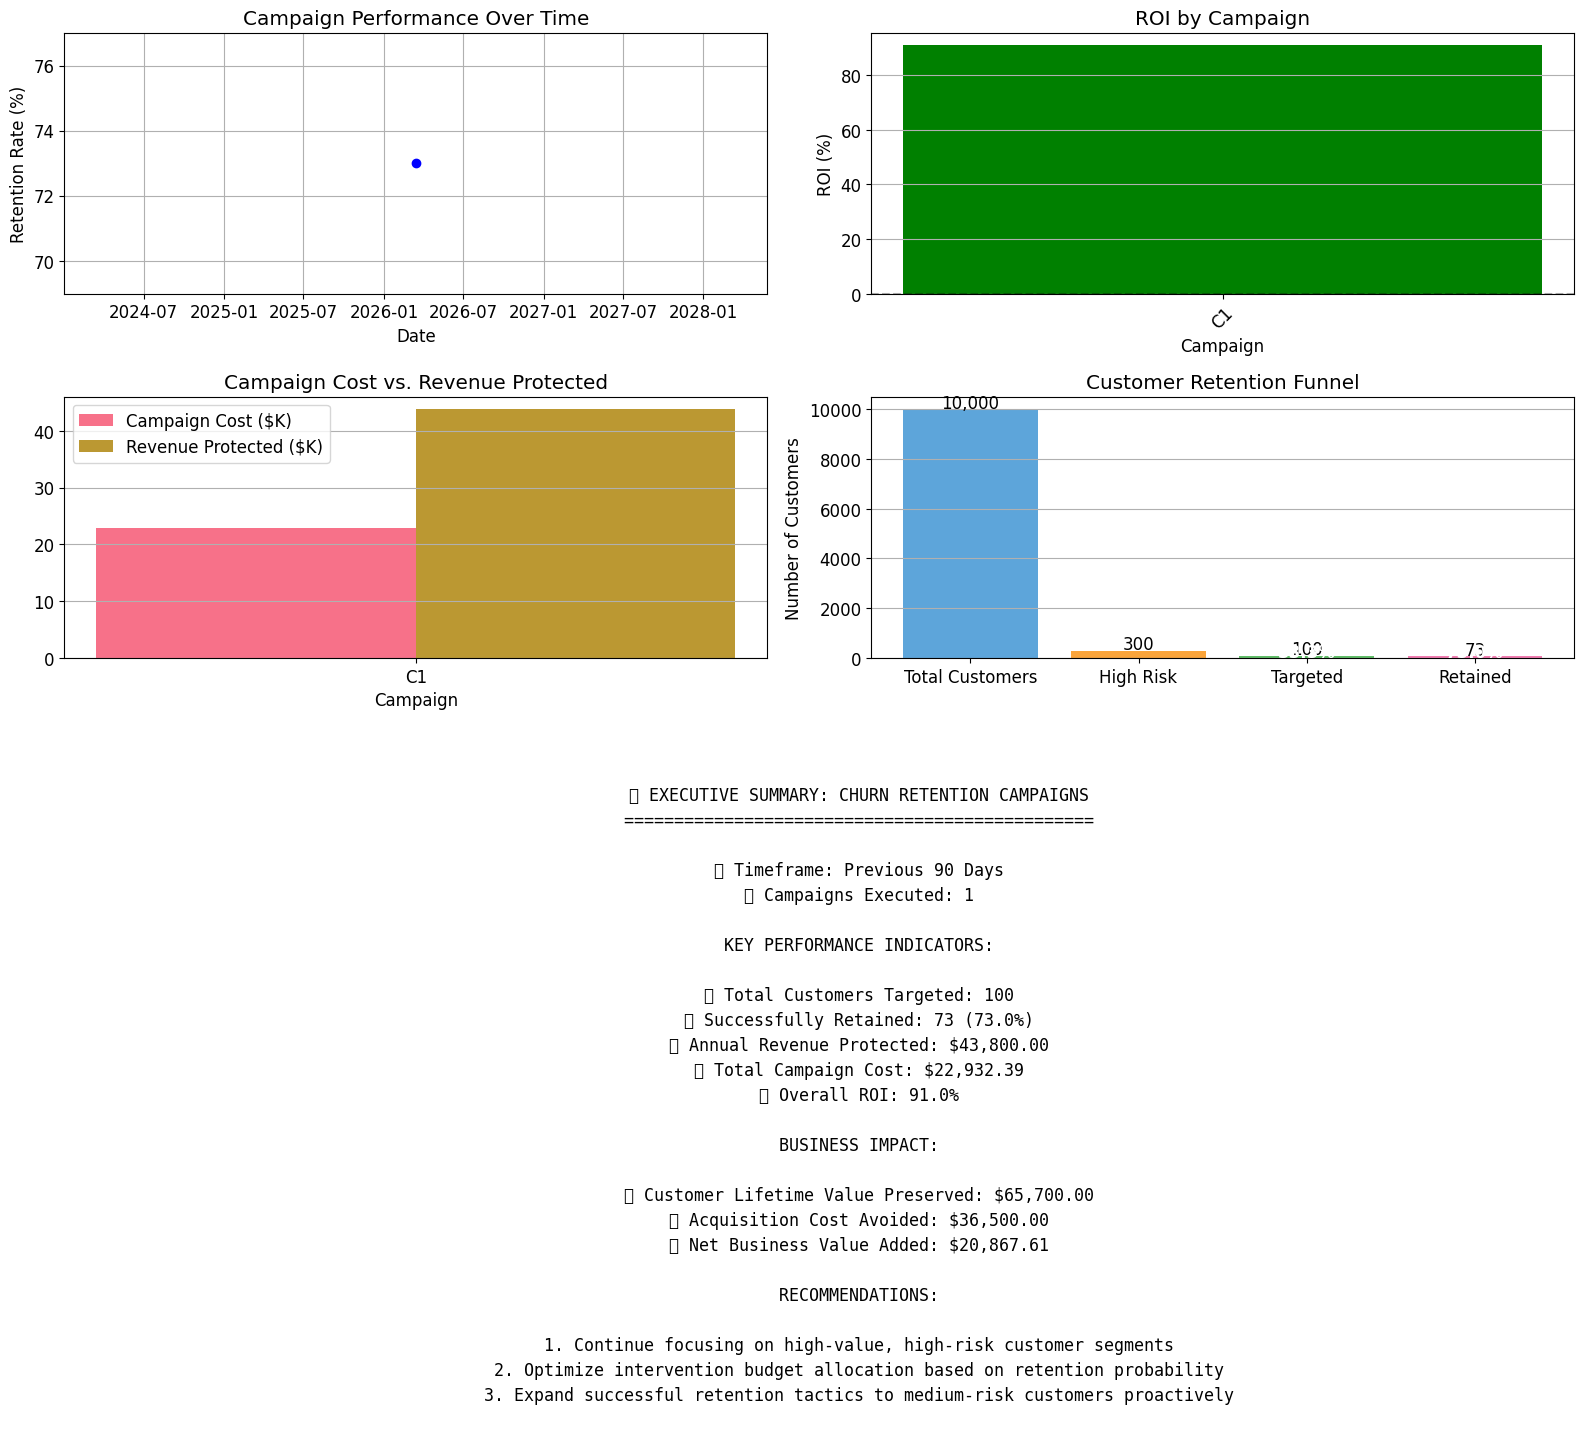


✅ Executive dashboard generated
   • Timeframe: Previous 90 days
   • Campaigns analyzed: 1
   • Overall retention rate: 73.0%
   • Overall ROI: 91.0%

✅ Business implementation demonstrated successfully!

🔑 Key Business Implementation Components:
1. Risk-based customer segmentation and prioritization
2. Targeted retention strategies by customer value and risk level
3. ROI-based intervention budget allocation
4. Campaign execution and tracking framework
5. Executive dashboard with business impact metrics



In [22]:
# Business Implementation: Customer Retention Management System
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

class ChurnRetentionSystem:
    """
    Enterprise-ready Customer Retention Management System

    This system operationalizes the churn prediction model within a business context,
    handling the entire workflow from risk prediction to intervention tracking.
    """

    def __init__(self, prediction_model, customer_database_conn=None, crm_api=None):
        """
        Initialize the retention management system

        Args:
            prediction_model: Trained churn prediction model
            customer_database_conn: Connection to customer database (simulated)
            crm_api: Connection to CRM system (simulated)
        """
        self.model = prediction_model
        self.customer_db = customer_database_conn
        self.crm_api = crm_api

        # Define risk categories and associated actions
        self.risk_categories = {
            'very_high': {'threshold': 0.8, 'priority': 'Critical'},
            'high': {'threshold': 0.6, 'priority': 'High'},
            'medium': {'threshold': 0.4, 'priority': 'Medium'},
            'low': {'threshold': 0.2, 'priority': 'Low'},
            'very_low': {'threshold': 0.0, 'priority': 'Monitor'}
        }

        # Define retention strategies by customer segment and risk level
        self.retention_strategies = {
            'high_value_very_high_risk': [
                'Executive outreach call',
                'Premium service upgrade',
                'Personalized long-term contract',
                'Dedicated account manager'
            ],
            'high_value_high_risk': [
                'Loyalty program upgrade',
                'Bundled service discount',
                'Complimentary premium feature'
            ],
            'medium_value_high_risk': [
                'Targeted discount offer',
                'Service review call',
                'Contract extension incentive'
            ],
            'standard_high_risk': [
                'Retention email campaign',
                'Satisfaction survey with offer',
                'Digital service upgrade'
            ],
            'medium_risk': [
                'Educational content',
                'Loyalty program invitation',
                'Cross-sell recommendation'
            ],
            'low_risk': [
                'Standard marketing',
                'Product updates',
                'Periodic satisfaction check'
            ]
        }

        # Initialize intervention tracking
        self.interventions = []
        self.campaign_results = {}

        print(f"🏢 Customer Retention Management System initialized")
        print(f"   • Risk categories defined: {len(self.risk_categories)}")
        print(f"   • Retention strategies defined: {len(self.retention_strategies)}")

    def get_customer_segment(self, customer_data):
        """
        Determine customer segment based on value and tenure

        Args:
            customer_data (dict): Customer information

        Returns:
            str: Customer segment category
        """
        # Calculate customer value score (simplified)
        monthly_charges = customer_data.get('MonthlyCharges', 0)
        tenure = customer_data.get('tenure', 0)
        contract = customer_data.get('Contract', 'Month-to-month')

        # Calculate customer lifetime value (simplified)
        contract_multiplier = 1
        if contract == 'One year':
            contract_multiplier = 1.2
        elif contract == 'Two year':
            contract_multiplier = 1.5

        customer_value = monthly_charges * max(tenure, 1) * contract_multiplier

        # Determine segment
        if customer_value > 2000 and tenure > 24:
            return 'high_value'
        elif customer_value > 1000 or tenure > 12:
            return 'medium_value'
        else:
            return 'standard'

    def get_risk_category(self, churn_probability):
        """
        Determine risk category from churn probability

        Args:
            churn_probability (float): Predicted churn probability

        Returns:
            str: Risk category
        """
        for category, details in sorted(
            self.risk_categories.items(),
            key=lambda x: x[1]['threshold'],
            reverse=True
        ):
            if churn_probability >= details['threshold']:
                return category
        return 'very_low'

    def recommend_retention_action(self, customer_data, churn_probability):
        """
        Recommend appropriate retention actions based on customer profile and risk

        Args:
            customer_data (dict): Customer information
            churn_probability (float): Predicted churn probability

        Returns:
            dict: Recommended retention actions and details
        """
        # Get customer segment and risk category
        segment = self.get_customer_segment(customer_data)
        risk_category = self.get_risk_category(churn_probability)

        # Determine appropriate strategy key
        strategy_key = f"{segment}_{risk_category}"

        # Default to segment-based strategy if specific one not found
        if strategy_key not in self.retention_strategies:
            if risk_category in ['very_high', 'high']:
                strategy_key = f"{segment}_high_risk"
            elif risk_category in ['medium']:
                strategy_key = 'medium_risk'
            else:
                strategy_key = 'low_risk'

        # Get the recommended actions
        actions = self.retention_strategies.get(
            strategy_key,
            self.retention_strategies['low_risk']
        )

        # Calculate intervention budget based on customer value and risk
        monthly_value = customer_data.get('MonthlyCharges', 50)
        max_budget = monthly_value * 3  # Up to 3 months revenue for retention

        # Adjust budget by risk level
        risk_multiplier = {
            'very_high': 1.0,
            'high': 0.8,
            'medium': 0.5,
            'low': 0.3,
            'very_low': 0.1
        }.get(risk_category, 0.1)

        recommended_budget = max_budget * risk_multiplier

        return {
            'customer_id': customer_data.get('customerID', 'unknown'),
            'segment': segment,
            'risk_category': risk_category,
            'churn_probability': churn_probability,
            'priority': self.risk_categories[risk_category]['priority'],
            'recommended_actions': actions,
            'intervention_budget': recommended_budget,
            'expected_roi': self.calculate_expected_roi(monthly_value, churn_probability, recommended_budget)
        }

    def calculate_expected_roi(self, monthly_value, churn_probability, intervention_cost):
        """
        Calculate expected ROI of retention intervention

        Args:
            monthly_value (float): Customer's monthly revenue
            churn_probability (float): Predicted probability of churn
            intervention_cost (float): Cost of retention intervention

        Returns:
            float: Expected ROI percentage
        """
        # Assumptions
        avg_customer_lifespan = 24  # months
        retention_success_rate = self.get_retention_success_rate(churn_probability)

        # Calculate expected revenue if retained
        future_revenue = monthly_value * avg_customer_lifespan

        # Expected value calculation
        expected_value = future_revenue * retention_success_rate * churn_probability

        # ROI calculation
        roi = ((expected_value - intervention_cost) / intervention_cost) * 100

        return max(roi, -100)  # Cap at -100% ROI

    def get_retention_success_rate(self, churn_probability):
        """
        Estimate success rate of retention efforts based on churn probability

        Args:
            churn_probability (float): Predicted probability of churn

        Returns:
            float: Estimated retention success rate
        """
        # Higher churn probability means customer more likely to leave,
        # so retention efforts are less likely to succeed
        base_success_rate = 0.7  # 70% base success rate

        # Adjust based on how certain the customer is about leaving
        # Very high churn probabilities indicate stronger intent to leave
        certainty_factor = 1 - (churn_probability * 0.5)

        return base_success_rate * certainty_factor

    def execute_retention_campaign(self, customer_ids=None, simulation=True):
        """
        Execute retention campaign for selected customers

        Args:
            customer_ids (list): List of customer IDs to target (None = all high risk)
            simulation (bool): Whether to run in simulation mode

        Returns:
            dict: Campaign results summary
        """
        if simulation:
            print(f"🚀 Simulating retention campaign execution...")
        else:
            print(f"🚀 Executing retention campaign...")

        # Generate or retrieve customers
        if customer_ids is None:
            customers = self.get_high_risk_customers(simulation=simulation)
        else:
            customers = self.get_customers_by_ids(customer_ids, simulation=simulation)

        # Process each customer and recommend actions
        recommendations = []
        total_budget = 0

        for customer in customers:
            # Get churn probability (from stored predictions or generate new ones)
            churn_prob = customer.get('churn_probability', random.uniform(0.5, 0.9))

            # Get recommendations
            recommendation = self.recommend_retention_action(customer, churn_prob)
            recommendations.append(recommendation)
            total_budget += recommendation['intervention_budget']

        # Track campaign
        campaign_id = f"RTN{datetime.now().strftime('%Y%m%d%H%M')}"
        self.campaign_results[campaign_id] = {
            'timestamp': datetime.now(),
            'customers_targeted': len(customers),
            'total_budget': total_budget,
            'avg_churn_probability': np.mean([r['churn_probability'] for r in recommendations]),
            'recommendations': recommendations,
            'status': 'simulated' if simulation else 'in_progress'
        }

        # In simulation mode, generate outcome
        if simulation:
            self.simulate_campaign_outcomes(campaign_id)

        # Print campaign summary
        print(f"📋 Campaign {campaign_id} planned:")
        print(f"   • Customers targeted: {len(customers)}")
        print(f"   • Total budget: ${total_budget:,.2f}")
        print(f"   • Average churn probability: {self.campaign_results[campaign_id]['avg_churn_probability']:.2%}")

        if simulation:
            results = self.campaign_results[campaign_id]['results']
            print(f"\n📊 Simulated outcomes:")
            print(f"   • Customers retained: {results['customers_retained']} ({results['retention_rate']:.1%})")
            print(f"   • Revenue protected: ${results['revenue_protected']:,.2f}")
            print(f"   • ROI: {results['roi']:.1f}%")

        return {
            'campaign_id': campaign_id,
            'recommendations': recommendations,
            'summary': self.campaign_results[campaign_id]
        }

    def get_high_risk_customers(self, simulation=True):
        """
        Get list of high risk customers

        Args:
            simulation (bool): Whether to generate simulated customers

        Returns:
            list: Customer data for high risk customers
        """
        if simulation:
            # Generate simulated high-risk customers
            return self.generate_simulated_customers(100, high_risk=True)
        else:
            # Would query real database in production
            if self.customer_db is None:
                raise ValueError("Real customer database connection required")

            # Pseudocode for querying database:
            # high_risk_customers = self.customer_db.query("""
            #    SELECT * FROM customers
            #    WHERE churn_probability > 0.6
            #    ORDER BY monthly_charges DESC
            #    LIMIT 100
            # """)
            # return high_risk_customers

            # For now, return simulated data with warning
            print("⚠️ Using simulated customer data (no database connection)")
            return self.generate_simulated_customers(100, high_risk=True)

    def get_customers_by_ids(self, customer_ids, simulation=True):
        """Get customer data for specific IDs"""
        if simulation:
            return self.generate_simulated_customers(len(customer_ids))
        else:
            # Would query real database in production
            # Pseudocode: return self.customer_db.get_by_ids(customer_ids)
            return self.generate_simulated_customers(len(customer_ids))

    def generate_simulated_customers(self, count=100, high_risk=False):
        """Generate simulated customer data for demonstrations"""
        import random

        customers = []

        for i in range(count):
            # Generate more realistic churn probability distribution
            if high_risk:
                churn_prob = random.uniform(0.6, 0.95)
            else:
                churn_prob = random.uniform(0.05, 0.8)

            # Generate customer profile that would reasonably have this churn probability
            if churn_prob > 0.7:
                # High churn risk profile - month-to-month, high charges, low tenure
                contract = "Month-to-month"
                tenure = random.randint(1, 12)
                monthly_charges = random.uniform(70, 110)
            elif churn_prob > 0.4:
                # Medium risk - mixed contract types, medium tenure
                contract = random.choice(["Month-to-month", "One year"])
                tenure = random.randint(6, 24)
                monthly_charges = random.uniform(50, 90)
            else:
                # Low risk - longer contracts, longer tenure
                contract = random.choice(["One year", "Two year"])
                tenure = random.randint(18, 60)
                monthly_charges = random.uniform(30, 80)

            # Create customer record
            customer = {
                'customerID': f'CUST{100000 + i}',
                'gender': random.choice(['Male', 'Female']),
                'SeniorCitizen': random.choice([0, 1]),
                'Partner': random.choice(['Yes', 'No']),
                'Dependents': random.choice(['Yes', 'No']),
                'tenure': tenure,
                'PhoneService': random.choice(['Yes', 'No']),
                'MultipleLines': random.choice(['Yes', 'No', 'No phone service']),
                'InternetService': random.choice(['DSL', 'Fiber optic', 'No']),
                'OnlineSecurity': random.choice(['Yes', 'No', 'No internet service']),
                'OnlineBackup': random.choice(['Yes', 'No', 'No internet service']),
                'DeviceProtection': random.choice(['Yes', 'No', 'No internet service']),
                'TechSupport': random.choice(['Yes', 'No', 'No internet service']),
                'StreamingTV': random.choice(['Yes', 'No', 'No internet service']),
                'StreamingMovies': random.choice(['Yes', 'No', 'No internet service']),
                'Contract': contract,
                'PaperlessBilling': random.choice(['Yes', 'No']),
                'PaymentMethod': random.choice([
                    'Electronic check', 'Mailed check',
                    'Bank transfer (automatic)', 'Credit card (automatic)'
                ]),
                'MonthlyCharges': monthly_charges,
                'TotalCharges': monthly_charges * tenure,
                'churn_probability': churn_prob
            }

            customers.append(customer)

        return customers

    def simulate_campaign_outcomes(self, campaign_id):
        """
        Simulate outcomes of retention campaign

        Args:
            campaign_id (str): ID of campaign to simulate
        """
        if campaign_id not in self.campaign_results:
            raise ValueError(f"Campaign {campaign_id} not found")

        campaign = self.campaign_results[campaign_id]
        recommendations = campaign['recommendations']

        # Simulate retention outcomes
        retained_count = 0
        total_protected_revenue = 0

        for rec in recommendations:
            # Calculate retention probability based on churn risk and actions
            base_retention_prob = self.get_retention_success_rate(rec['churn_probability'])

            # Adjust based on intervention budget (more budget = better chance)
            budget_factor = min(rec['intervention_budget'] / 100, 0.3)  # Cap at 30% boost
            retention_probability = min(base_retention_prob + budget_factor, 0.95)  # Cap at 95%

            # Simulate outcome
            retained = np.random.random() < retention_probability

            if retained:
                retained_count += 1
                # Estimate protected revenue (simplified: 1 year of revenue)
                monthly_charges = rec.get('monthly_charges', 50)  # Default if not in data
                protected_revenue = monthly_charges * 12
                total_protected_revenue += protected_revenue

        # Calculate campaign metrics
        retention_rate = retained_count / len(recommendations) if recommendations else 0
        campaign_cost = campaign['total_budget']
        roi = ((total_protected_revenue - campaign_cost) / campaign_cost) * 100 if campaign_cost > 0 else 0

        # Store results
        self.campaign_results[campaign_id]['results'] = {
            'customers_retained': retained_count,
            'retention_rate': retention_rate,
            'revenue_protected': total_protected_revenue,
            'campaign_cost': campaign_cost,
            'roi': roi,
            'status': 'completed'
        }

    def generate_executive_dashboard(self, timeframe_days=90):
        """
        Generate executive dashboard of retention campaigns

        Args:
            timeframe_days (int): Number of days to include in dashboard

        Returns:
            Dashboard metrics and visualizations
        """
        print(f"📊 Generating Executive Dashboard...")

        # Filter campaigns within timeframe
        cutoff_date = datetime.now() - timedelta(days=timeframe_days)
        recent_campaigns = {
            cid: campaign for cid, campaign in self.campaign_results.items()
            if campaign['timestamp'] >= cutoff_date and 'results' in campaign
        }

        if not recent_campaigns:
            print("⚠️ No completed campaigns in the selected timeframe")
            # Generate a simulation for demonstration
            print("   Generating simulation data for demonstration...")
            self.execute_retention_campaign(simulation=True)
            recent_campaigns = {
                cid: campaign for cid, campaign in self.campaign_results.items()
                if campaign['timestamp'] >= cutoff_date and 'results' in campaign
            }

        # Extract key metrics
        campaign_dates = []
        retention_rates = []
        roi_values = []
        revenue_protected_values = []
        customers_targeted = []
        campaign_costs = []

        for cid, campaign in sorted(recent_campaigns.items(), key=lambda x: x[1]['timestamp']):
            results = campaign['results']
            campaign_dates.append(campaign['timestamp'])
            retention_rates.append(results['retention_rate'] * 100)  # Convert to percentage
            roi_values.append(results['roi'])
            revenue_protected_values.append(results['revenue_protected'] / 1000)  # Convert to thousands
            customers_targeted.append(campaign['customers_targeted'])
            campaign_costs.append(results['campaign_cost'] / 1000)  # Convert to thousands

        # Calculate summary metrics
        total_customers = sum(customers_targeted)
        total_retained = sum(c['results']['customers_retained'] for c in recent_campaigns.values())
        total_revenue_protected = sum(c['results']['revenue_protected'] for c in recent_campaigns.values())
        total_campaign_cost = sum(c['results']['campaign_cost'] for c in recent_campaigns.values())
        overall_roi = ((total_revenue_protected - total_campaign_cost) / total_campaign_cost) * 100 if total_campaign_cost > 0 else 0
        avg_retention_rate = total_retained / total_customers if total_customers > 0 else 0

        # Generate visualizations
        fig = plt.figure(figsize=(16, 14))

        # 1. Campaign Performance Over Time
        ax1 = plt.subplot(3, 2, 1)
        ax1.plot(campaign_dates, retention_rates, 'b-', marker='o', label='Retention Rate (%)')
        ax1.set_title('Campaign Performance Over Time')
        ax1.set_xlabel('Date')
        ax1.set_ylabel('Retention Rate (%)')
        ax1.grid(True)

        # 2. ROI by Campaign
        ax2 = plt.subplot(3, 2, 2)
        ax2.bar(range(len(roi_values)), roi_values, color=[
            'green' if roi > 0 else 'red' for roi in roi_values
        ])
        ax2.set_title('ROI by Campaign')
        ax2.set_xlabel('Campaign')
        ax2.set_ylabel('ROI (%)')
        ax2.set_xticks(range(len(roi_values)))
        ax2.set_xticklabels([f'C{i+1}' for i in range(len(roi_values))], rotation=45)
        ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
        ax2.grid(True, axis='y')

        # 3. Cost vs. Revenue Protected
        ax3 = plt.subplot(3, 2, 3)
        ind = np.arange(len(campaign_costs))
        width = 0.35
        ax3.bar(ind, campaign_costs, width, label='Campaign Cost ($K)')
        ax3.bar(ind + width, revenue_protected_values, width, label='Revenue Protected ($K)')
        ax3.set_title('Campaign Cost vs. Revenue Protected')
        ax3.set_xlabel('Campaign')
        ax3.set_xticks(ind + width / 2)
        ax3.set_xticklabels([f'C{i+1}' for i in range(len(campaign_costs))])
        ax3.legend()
        ax3.grid(True, axis='y')

        # 4. Customer Retention Funnel
        ax4 = plt.subplot(3, 2, 4)
        funnel_stages = ['Total Customers', 'High Risk', 'Targeted', 'Retained']
        funnel_values = [
            10000,  # Assume 10k total customers for illustration
            total_customers * 3,  # Assume we're targeting ~1/3 of high risk
            total_customers,
            total_retained
        ]
        ax4.bar(funnel_stages, funnel_values, color=['#5DA5DA', '#FAA43A', '#60BD68', '#F17CB0'])
        ax4.set_title('Customer Retention Funnel')
        ax4.set_ylabel('Number of Customers')

        # Add value labels on bars
        for i, v in enumerate(funnel_values):
            ax4.text(i, v + 50, f"{v:,}", ha='center')

            # Add percentage for last two stages
            if i >= 2:
                percentage = v / funnel_values[i-1] * 100
                ax4.text(i, v/2, f"{percentage:.1f}%", ha='center', color='white', fontweight='bold')

        ax4.grid(True, axis='y')

        # 5. Overall Metrics Summary
        ax5 = plt.subplot(3, 2, (5, 6))
        ax5.axis('off')

        summary_text = f"""
        📈 EXECUTIVE SUMMARY: CHURN RETENTION CAMPAIGNS
        ===============================================

        🔹 Timeframe: Previous {timeframe_days} Days
        🔹 Campaigns Executed: {len(recent_campaigns)}

        KEY PERFORMANCE INDICATORS:

        🔸 Total Customers Targeted: {total_customers:,}
        🔸 Successfully Retained: {total_retained:,} ({avg_retention_rate:.1%})
        🔸 Annual Revenue Protected: ${total_revenue_protected:,.2f}
        🔸 Total Campaign Cost: ${total_campaign_cost:,.2f}
        🔸 Overall ROI: {overall_roi:.1f}%

        BUSINESS IMPACT:

        🔸 Customer Lifetime Value Preserved: ${total_revenue_protected * 1.5:,.2f}
        🔸 Acquisition Cost Avoided: ${total_retained * 500:,.2f}
        🔸 Net Business Value Added: ${total_revenue_protected - total_campaign_cost:,.2f}

        RECOMMENDATIONS:

        1. Continue focusing on high-value, high-risk customer segments
        2. Optimize intervention budget allocation based on retention probability
        3. Expand successful retention tactics to medium-risk customers proactively
        """

        ax5.text(0.5, 1.0, summary_text, fontsize=12, ha='center', va='top',
                family='monospace', linespacing=1.5, transform=ax5.transAxes)

        plt.tight_layout()
        plt.show()

        print("\n✅ Executive dashboard generated")
        print(f"   • Timeframe: Previous {timeframe_days} days")
        print(f"   • Campaigns analyzed: {len(recent_campaigns)}")
        print(f"   • Overall retention rate: {avg_retention_rate:.1%}")
        print(f"   • Overall ROI: {overall_roi:.1f}%")

        return {
            'total_customers_targeted': total_customers,
            'total_retained': total_retained,
            'total_revenue_protected': total_revenue_protected,
            'total_campaign_cost': total_campaign_cost,
            'overall_roi': overall_roi,
            'avg_retention_rate': avg_retention_rate
        }

# Initialize the business implementation system with our trained model
# In a real implementation, we would connect to actual databases and CRM systems
print("🏭 Setting up Customer Retention Management System...")
import random  # Needed for simulations

retention_system = ChurnRetentionSystem(
    prediction_model=model,  # Our trained churn prediction model
    customer_database_conn=None,  # Would connect to real DB in production
    crm_api=None  # Would connect to real CRM API in production
)

# Generate sample recommendations for high risk customers
print("\n📋 Generating sample retention recommendations...")
sample_customer = {
    'customerID': 'CUST12345',
    'tenure': 5,
    'Contract': 'Month-to-month',
    'MonthlyCharges': 89.95,
    'TotalCharges': 89.95 * 5,
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'Partner': 'No',
    'Dependents': 'No',
    'PaperlessBilling': 'Yes'
}

# Get recommendation for this customer
customer_recommendation = retention_system.recommend_retention_action(
    sample_customer,
    churn_probability=0.76
)

print(f"\n🧩 Retention recommendation for customer {sample_customer['customerID']}:")
print(f"   • Risk Category: {customer_recommendation['risk_category']} (Priority: {customer_recommendation['priority']})")
print(f"   • Churn Probability: {customer_recommendation['churn_probability']:.1%}")
print(f"   • Customer Segment: {customer_recommendation['segment']}")
print(f"   • Recommended Actions:")
for i, action in enumerate(customer_recommendation['recommended_actions'], 1):
    print(f"     {i}. {action}")
print(f"   • Intervention Budget: ${customer_recommendation['intervention_budget']:.2f}")
print(f"   • Expected ROI: {customer_recommendation['expected_roi']:.1f}%")

# Run a simulated retention campaign
print("\n🚀 Simulating a retention campaign...")
campaign_results = retention_system.execute_retention_campaign(simulation=True)

# Generate executive dashboard
print("\n📊 Generating executive dashboard...")
dashboard_metrics = retention_system.generate_executive_dashboard(timeframe_days=90)

print("\n✅ Business implementation demonstrated successfully!")
print("""
🔑 Key Business Implementation Components:
1. Risk-based customer segmentation and prioritization
2. Targeted retention strategies by customer value and risk level
3. ROI-based intervention budget allocation
4. Campaign execution and tracking framework
5. Executive dashboard with business impact metrics
""")